In [1]:
#这里是持久卷，因为担心bug就没删除
import os, sys, IPython
import timm
from timm.models.swin_transformer import SwinTransformer, SwinTransformerBlock
print(f"✅ timm版本: {timm.__version__}")
print("✅ Swin Transformer可用")
# --- OFFLINE MODE HELPERS (inserted) ---
# Set OFFLINE = True to force using local files and disable any internet download attempts.
OFFLINE = True

# Persistent storage path provided by your school GPU platform.
# Change this if your platform mounts a different persistent volume.
PERSISTENT_PATH = "/mnt/data/persistent"
os.makedirs(PERSISTENT_PATH, exist_ok=True)

# Data root: where you should place the dataset (same structure as original).
DATA_ROOT = os.path.join(PERSISTENT_PATH, "dataset")  # <-- put your dataset here
WEIGHTS_DIR = os.path.join(PERSISTENT_PATH, "weights")  # <-- put model weights (e.g., SAM) here
LOG_DIR = os.path.join(PERSISTENT_PATH, "logs")
CHECKPOINT_DIR = os.path.join(PERSISTENT_PATH, "checkpoints")
OUT_DIR = os.path.join(PERSISTENT_PATH, "output")
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

print("OFFLINE mode:", OFFLINE)
print("PERSISTENT_PATH:", PERSISTENT_PATH)
print("DATA_ROOT:", DATA_ROOT)
print("WEIGHTS_DIR:", WEIGHTS_DIR)
print("LOG_DIR:", LOG_DIR)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("OUT_DIR",OUT_DIR)

def require_local_file(path, hint=""):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Required local file not found: {path}. {hint}")


✅ timm版本: 0.9.12
✅ Swin Transformer可用
OFFLINE mode: True
PERSISTENT_PATH: /mnt/data/persistent
DATA_ROOT: /mnt/data/persistent/dataset
WEIGHTS_DIR: /mnt/data/persistent/weights
LOG_DIR: /mnt/data/persistent/logs
CHECKPOINT_DIR: /mnt/data/persistent/checkpoints
OUT_DIR /mnt/data/persistent/output


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os

# === 改动部分开始 ===
# 使用当前工作目录作为根路径
PROJECT_ROOT = os.getcwd()
print("📁 当前项目根目录:", PROJECT_ROOT)

DATA_ROOT = os.path.join(PROJECT_ROOT, "MICCAI_BraTS2020_TrainingData")
WEIGHTS_DIR = os.path.join(PROJECT_ROOT, "weights")
LOG_DIR = os.path.join(PROJECT_ROOT, "logs")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
OUT_DIR = os.path.join(PROJECT_ROOT, "output")
for d in [DATA_ROOT, WEIGHTS_DIR, LOG_DIR, CHECKPOINT_DIR,OUT_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f"✅ {d} 已创建（若已存在则跳过）")



📁 当前项目根目录: /storage/main/users/leishen
✅ /storage/main/users/leishen/MICCAI_BraTS2020_TrainingData 已创建（若已存在则跳过）
✅ /storage/main/users/leishen/weights 已创建（若已存在则跳过）
✅ /storage/main/users/leishen/logs 已创建（若已存在则跳过）
✅ /storage/main/users/leishen/checkpoints 已创建（若已存在则跳过）
✅ /storage/main/users/leishen/output 已创建（若已存在则跳过）


In [3]:
import os, tempfile, time

# --- Test read/write access for persistent directories ---
paths = {
    "DATA_ROOT": DATA_ROOT,
    "WEIGHTS_DIR": WEIGHTS_DIR,
    "LOG_DIR": LOG_DIR,
    "CHECKPOINT_DIR": CHECKPOINT_DIR,
    "OUT_DIR":OUT_DIR
}

print("🧩 [1] 路径存在性与权限检查 Path existence & permissions test:")
for name, path in paths.items():
    print(f"  - {name}: {path}")
    print(f"    Exists: {os.path.exists(path)} | Writable: {os.access(path, os.W_OK)} | Absolute: {os.path.abspath(path)}")

print("\n🧩 [2] 读写测试 Read/Write test:")
for name, path in paths.items():
    try:
        test_file = os.path.join(path, f"test_{int(time.time())}.txt")
        with open(test_file, "w") as f:
            f.write(f"Hello from {name} at {time.ctime()}\n")
        with open(test_file, "r") as f:
            content = f.read().strip()
        print(f"  ✅ {name} 写入并读取成功! 内容: {content}")
        os.remove(test_file)
    except Exception as e:
        print(f"  ❌ {name} 写入失败: {e}")

print("\n🧩 [3] 核心路径验证完毕，如果都为 ✅，说明持久卷配置无问题。")


🧩 [1] 路径存在性与权限检查 Path existence & permissions test:
  - DATA_ROOT: /storage/main/users/leishen/MICCAI_BraTS2020_TrainingData
    Exists: True | Writable: True | Absolute: /storage/main/users/leishen/MICCAI_BraTS2020_TrainingData
  - WEIGHTS_DIR: /storage/main/users/leishen/weights
    Exists: True | Writable: True | Absolute: /storage/main/users/leishen/weights
  - LOG_DIR: /storage/main/users/leishen/logs
    Exists: True | Writable: True | Absolute: /storage/main/users/leishen/logs
  - CHECKPOINT_DIR: /storage/main/users/leishen/checkpoints
    Exists: True | Writable: True | Absolute: /storage/main/users/leishen/checkpoints
  - OUT_DIR: /storage/main/users/leishen/output
    Exists: True | Writable: True | Absolute: /storage/main/users/leishen/output

🧩 [2] 读写测试 Read/Write test:
  ✅ DATA_ROOT 写入并读取成功! 内容: Hello from DATA_ROOT at Thu Jan 15 14:58:58 2026
  ✅ WEIGHTS_DIR 写入并读取成功! 内容: Hello from WEIGHTS_DIR at Thu Jan 15 14:58:58 2026
  ✅ LOG_DIR 写入并读取成功! 内容: Hello from LOG_DIR at Thu 

In [4]:
'''
# --- TensorBoard initialization for offline logging ---
from torch.utils.tensorboard import SummaryWriter
# Use LOG_DIR from OFFLINE helper
tb_log_dir = LOG_DIR
os.makedirs(tb_log_dir, exist_ok=True)
writer = SummaryWriter(tb_log_dir)

def log_metrics(metrics: dict, step: int = None):
    """
    metrics: dict of {name: scalar}
    step: int, optional training step or epoch
    """
    if step is None:
        # try to infer a step from metrics if present
        step = metrics.pop('step', None)
    for k, v in metrics.items():
        try:
            writer.add_scalar(k, float(v), global_step=step if step is not None else 0)
        except Exception as e:
            print(f"Failed to write metric {k}: {e}")
    # also print to console for immediate feedback
    print("LOG:", {"step": step, **{k: float(v) for k, v in metrics.items()}})
'''

'\n# --- TensorBoard initialization for offline logging ---\nfrom torch.utils.tensorboard import SummaryWriter\n# Use LOG_DIR from OFFLINE helper\ntb_log_dir = LOG_DIR\nos.makedirs(tb_log_dir, exist_ok=True)\nwriter = SummaryWriter(tb_log_dir)\n\ndef log_metrics(metrics: dict, step: int = None):\n    """\n    metrics: dict of {name: scalar}\n    step: int, optional training step or epoch\n    """\n    if step is None:\n        # try to infer a step from metrics if present\n        step = metrics.pop(\'step\', None)\n    for k, v in metrics.items():\n        try:\n            writer.add_scalar(k, float(v), global_step=step if step is not None else 0)\n        except Exception as e:\n            print(f"Failed to write metric {k}: {e}")\n    # also print to console for immediate feedback\n    print("LOG:", {"step": step, **{k: float(v) for k, v in metrics.items()}})\n'

In [5]:
import csv

with open(os.path.join(LOG_DIR, "training_log.csv"), "a") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "val_dice"])


## Offline adaptation summary (auto-inserted)

我已将 notebook 自动调整为**离线模式 (OFFLINE=True)**：
- 在文档顶部添加了 OFFLINE、PERSISTENT_PATH、DATA_ROOT、WEIGHTS_DIR、LOG_DIR、CHECKPOINT_DIR 变量，请将数据集和模型权重放入这些目录。
- 移除了或替换了常见的网络下载命令（wget/gdown/requests/kaggle/hf_hub），并在原处放置了提示。  
- 将 wandb 等在线日志替换为本地打印/建议使用 TensorBoard。  
- 所有模型保存路径被重定向到 CHECKPOINT_DIR。  
- 如果 notebook 仍包含未替换的在线调用，请手动把相应文件复制到 `WEIGHTS_DIR` 或 `DATA_ROOT`。

请下载并检查生成的文件 `cov_sam_swin_offline.ipynb`，在运行前将数据集放到 `PERSISTENT_PATH/dataset`，并把 SAM 等权重放到 `PERSISTENT_PATH/weights`。


In [6]:
import os, sys, torch, numpy as np, random
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
print("Python :", sys.version)
print("Torch  :", torch.__version__, "| CUDA:", torch.version.cuda, "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
torch.set_float32_matmul_precision("high")

Python : 3.10.12 (main, Aug 15 2025, 14:32:43) [GCC 11.4.0]
Torch  : 2.6.0+cu124 | CUDA: 12.4 | GPU: NVIDIA L20


In [7]:
import importlib, subprocess, sys

def ensure_pkg(spec, import_name=None):
    name = import_name or spec.split("==")[0].split(">=")[0].split("[")[0]
    try:
        m = importlib.import_module(name)
        print(f"[OK] {name} @ {m.__file__}")
        return m
    except Exception as e:
        print(f"[INSTALL] {spec}  (reason: {e})")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-qU", "--no-cache-dir", spec])
        m = importlib.import_module(name)
        print(f"[OK] {name} @ {m.__file__}")
        return m

monai = ensure_pkg("monai>=1.4.0", "monai")
tm    = ensure_pkg("torchmetrics>=1.3.0,<2.0", "torchmetrics")

try:
    import segment_anything as samlib
    print("[OK] segment_anything @", samlib.__file__)
except Exception as e:
    print("[WARN] segment_anything not found -> installing from GitHub...", e)
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir",
                               "git+https://github.com/facebookresearch/segment-anything.git"])
        import segment_anything as samlib
        print("[OK] segment_anything @", samlib.__file__)
    except Exception as e2:
        print("[WARN] online install failed:", e2)
        try:
            import segment_anything as samlib
            print("[OK] segment_anything (offline path)")
        except Exception as e3:
            print("[FALLBACK] internal tiny encoder. reason:", repr(e3))

import nibabel as nib
print("MONAI :", monai.__version__)
print("TM    :", tm.__version__)

[OK] monai @ /usr/local/lib/python3.10/dist-packages/monai/__init__.py
[OK] torchmetrics @ /usr/local/lib/python3.10/dist-packages/torchmetrics/__init__.py
[OK] segment_anything @ /usr/local/lib/python3.10/dist-packages/segment_anything/__init__.py
MONAI : 1.5.1
TM    : 1.8.2


In [8]:
ensure_pkg("scipy>=1.7.0", "scipy")
ensure_pkg("pandas>=1.3.0", "pandas")
ensure_pkg("seaborn>=0.11.0", "seaborn")

[OK] scipy @ /usr/local/lib/python3.10/dist-packages/scipy/__init__.py
[OK] pandas @ /usr/local/lib/python3.10/dist-packages/pandas/__init__.py
[OK] seaborn @ /usr/local/lib/python3.10/dist-packages/seaborn/__init__.py


<module 'seaborn' from '/usr/local/lib/python3.10/dist-packages/seaborn/__init__.py'>

In [9]:
from pathlib import Path
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

SEGMENT_CLASSES = {0:'NOT tumor', 1:'NECROTIC/CORE', 2:'EDEMA', 3:'ENHANCING'}
NUM_CLASSES = len(SEGMENT_CLASSES)
INCLUDE_BACKGROUND = True

IMAGE_SIZE      = 1024
BATCH_SIZE      = 1
EPOCHS          = 40
BASE_LR         = 2e-4
WEIGHT_DECAY    = 1e-4
USE_AMP         = False

# 编码器冻结策略
FREEZE_ENCODER  = True      # 是否冻结编码器
UNFREEZE_LAYERS = 2         # 解冻最后N层 (0表示全部冻结)

POS_NEG_RATIO   = 1.5
NUM_WORKERS     = 2

#OUT_DIR = Path("/kaggle/working/sam_unet"); OUT_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:

import re, random
from pathlib import Path

def is_str_list(x):
    return isinstance(x, (list, tuple)) and len(x)>0 and all(isinstance(s, str) and (s.endswith('.nii') or s.endswith('.nii.gz')) for s in x)

train_files_dict = None; val_files_dict = None; DATASET_MODE=None; IN_CHANNELS=None
g = globals()

# 1) dict 列表
if 'train_files' in g and 'val_files' in g and isinstance(g['train_files'], (list,tuple)) and g['train_files'] and isinstance(g['train_files'][0], dict):
    train_files_dict = g['train_files']; val_files_dict = g['val_files']
    one = train_files_dict[0]['image']
    IN_CHANNELS = len(one) if isinstance(one, (list,tuple)) else 1
    DATASET_MODE = 'brats' if IN_CHANNELS==4 else 'simple'

# 2) 成对列表
if train_files_dict is None:
    imgs = [k for k in g.keys() if re.search(r'(train).*(image|img)', k, re.I)]
    lbls = [k for k in g.keys() if re.search(r'(train).*(label|mask|seg)', k, re.I)]
    vimgs= [k for k in g.keys() if re.search(r'(val|valid).*(image|img)', k, re.I)]
    vlbls= [k for k in g.keys() if re.search(r'(val|valid).*(label|mask|seg)', k, re.I)]
    pair=None; vpair=None
    for ik in imgs:
        for lk in lbls:
            if is_str_list(g[ik]) and is_str_list(g[lk]) and len(g[ik])==len(g[lk]):
                pair=(ik,lk); break
        if pair: break
    for ik in vimgs:
        for lk in vlbls:
            if is_str_list(g[ik]) and is_str_list(g[lk]) and len(g[ik])==len(g[lk]):
                vpair=(ik,lk); break
        if vpair: break
    if pair and vpair:
        def to_dict_list(im, lb): return [{'image':i,'label':l} for i,l in zip(im,lb)]
        train_files_dict = to_dict_list(g[pair[0]], g[pair[1]])
        val_files_dict   = to_dict_list(g[vpair[0]], g[vpair[1]])
        IN_CHANNELS=1; DATASET_MODE='simple'

# 3) 多模态键
if train_files_dict is None:
    def find_mod(prefix):
        for k,v in g.items():
            if is_str_list(v) and prefix in k.lower():
                return k
        return None
    mods = {m: find_mod(m) for m in ['flair','t1ce','t1','t2','label']}
    vmods= {m: find_mod('val_'+m) for m in ['flair','t1ce','t1','t2','label']}
    if all(mods[m] for m in mods) and all(vmods[m] for m in vmods):
        def pack(mod):
            n = min(len(g[mod['flair']]), len(g[mod['t1']]), len(g[mod['t1ce']]), len(g[mod['t2']]), len(g[mod['label']]))
            return [{'flair': g[mod['flair']][i], 't1': g[mod['t1']][i], 't1ce': g[mod['t1ce']][i], 't2': g[mod['t2']][i], 'label': g[mod['label']][i]} for i in range(n)]
        train_files_dict = pack(mods); val_files_dict = pack(vmods)
        IN_CHANNELS=4; DATASET_MODE='brats'

FOUND_FROM_STYLE = train_files_dict is not None and val_files_dict is not None
print('FOUND_FROM_STYLE=', FOUND_FROM_STYLE, '| MODE=', DATASET_MODE, '| IN_CHANNELS=', IN_CHANNELS)

# 回退 /kaggle/input
if not FOUND_FROM_STYLE:
    print('回退到 /kaggle/input 自动发现...')
    def build_simple_pairs(root):
        root = Path(root)
        idir, ldir = root/'imagesTr', root/'labelsTr'
        if idir.exists() and ldir.exists():
            imgs = sorted([str(p) for p in idir.rglob('*.nii*')])
            lbls = sorted([str(p) for p in ldir.rglob('*.nii*')])
            lm = {Path(f).stem:f for f in lbls}
            pairs=[]
            for f in imgs:
                stem = Path(f).stem
                stem_norm = re.sub(r'_000\d$', '', stem)
                gpath = lm.get(stem) or lm.get(stem_norm)
                if gpath: pairs.append({'image': f, 'label': gpath})
            return pairs
        return []
    def build_brats_pairs(root):
        root = Path(root); cases=[]
        for d in root.rglob('*'):
            if not d.is_dir(): continue
            flair=list(d.glob('*flair*.nii*')); t1=[p for p in d.glob('*t1*.nii*') if 't1ce' not in p.name.lower()]
            t1ce=list(d.glob('*t1ce*.nii*')); t2=list(d.glob('*t2*.nii*')); seg=list(d.glob('*seg*.nii*'))
            if flair and t1 and t1ce and t2 and seg:
                cases.append({'flair':str(flair[0]), 't1':str(t1[0]), 't1ce':str(t1ce[0]), 't2':str(t2[0]), 'label':str(seg[0])})
        return cases
    def build_nnunet_pairs(root):
        root = Path(root); idir, ldir = root/'imagesTr', root/'labelsTr'
        if not (idir.exists() and ldir.exists()): return []
        images = sorted([str(p) for p in idir.rglob('*.nii*')])
        labels = sorted([str(p) for p in ldir.rglob('*.nii*')])
        lm = {Path(f).stem:f for f in labels}
        buckets={}
        for f in images:
            m = re.match(r'(.+)_000([0-3])$', Path(f).stem)
            if m:
                case, idx = m.group(1), int(m.group(2))
                buckets.setdefault(case, {})[idx]=f
        cases=[]
        for case,ch in buckets.items():
            if all(i in ch for i in [0,1,2,3]):
                lbl = lm.get(case)
                if lbl: cases.append({'flair':ch[0],'t1':ch[1],'t1ce':ch[2],'t2':ch[3],'label':lbl})
        return cases
    candidates = [p for p in Path('/storage/main/users/leishen').glob('*') if p.is_dir()]
    candidates.sort(key=lambda p: sum(f.stat().st_size for f in p.rglob('*') if f.is_file()), reverse=True)
    DATA_DIR = str(candidates[0]) if candidates else '/storage/main/users/leishen'
    files = build_brats_pairs(DATA_DIR) or build_nnunet_pairs(DATA_DIR) or build_simple_pairs(DATA_DIR)
    if not files: raise FileNotFoundError('未找到 NIfTI 数据；请确认 /storage/main/users/leishen 下存在数据集。')
    if isinstance(files[0], dict) and 'flair' in files[0]:
        DATASET_MODE='brats'; IN_CHANNELS=4
    else:
        DATASET_MODE='simple'; IN_CHANNELS=1
    random.Random(SEED).shuffle(files)
    k = max(1, int(len(files)*0.8))
    train_files_dict, val_files_dict = files[:k], files[k:]
print('最终模式=', DATASET_MODE, '| IN_CHANNELS=', IN_CHANNELS)
print('示例条目:', train_files_dict[0] if train_files_dict else None)

FOUND_FROM_STYLE= False | MODE= None | IN_CHANNELS= None
回退到 /kaggle/input 自动发现...
最终模式= brats | IN_CHANNELS= 4
示例条目: {'flair': '/storage/main/users/leishen/MICCAI_BraTS2020_TrainingData/BraTS20_Training_297/BraTS20_Training_297_flair.nii', 't1': '/storage/main/users/leishen/MICCAI_BraTS2020_TrainingData/BraTS20_Training_297/BraTS20_Training_297_t1.nii', 't1ce': '/storage/main/users/leishen/MICCAI_BraTS2020_TrainingData/BraTS20_Training_297/BraTS20_Training_297_t1ce.nii', 't2': '/storage/main/users/leishen/MICCAI_BraTS2020_TrainingData/BraTS20_Training_297/BraTS20_Training_297_t2.nii', 'label': '/storage/main/users/leishen/MICCAI_BraTS2020_TrainingData/BraTS20_Training_297/BraTS20_Training_297_seg.nii'}


In [11]:

import numpy as np, nibabel as nib

def list_modal_keys(sample):
    return ['flair','t1','t1ce','t2'] if DATASET_MODE=='brats' else ['image']

def scan_slices(files, max_per_volume=None, pos_neg_ratio=1.5):
    items=[]; rng=np.random.default_rng(SEED)
    for fd in files:
        lab = nib.load(fd['label']).get_fdata().astype(np.int16)
        lab = np.where(lab==4, 3, lab)
        D = lab.shape[-1]
        pos = [z for z in range(D) if (lab[...,z]>0).any()]
        neg = [z for z in range(D) if not (lab[...,z]>0).any()]
        rng.shuffle(pos); rng.shuffle(neg)
        if max_per_volume:
            n_pos = min(len(pos), int(max_per_volume * pos_neg_ratio/(1+pos_neg_ratio)))
            n_neg = min(len(neg), max_per_volume - n_pos)
            pos,neg = pos[:n_pos], neg[:n_neg]
        else:
            neg = neg[:len(pos) or min(16,len(neg))]
        items += [(fd,z,1) for z in pos] + [(fd,z,0) for z in neg]
    rng.shuffle(items)
    return items

train_slices = scan_slices(train_files_dict, max_per_volume=64, pos_neg_ratio=POS_NEG_RATIO)
val_slices   = scan_slices(val_files_dict,   max_per_volume=32, pos_neg_ratio=POS_NEG_RATIO)
print(f"切片数: train={len(train_slices)}, val={len(val_slices)}")

切片数: train=18816, val=2368


In [12]:

import torch, numpy as np
from PIL import Image

def load_slice(fd, z):
    keys = list_modal_keys(fd)
    imgs=[]
    for k in keys:
        arr = nib.load(fd[k]).get_fdata().astype(np.float32)
        imgs.append(arr[..., z])
    image = np.stack(imgs, axis=0)  # (C,H,W)

    lab = nib.load(fd['label']).get_fdata().astype(np.int16)[..., z]
    lab = np.where(lab==4, 3, lab).astype(np.int64)
    return image, lab

def normalize_image(image):
    C,H,W = image.shape
    for c in range(C):
        x = image[c]; nz = x!=0
        if nz.any():
            lo,hi = np.percentile(x[nz], 1.0), np.percentile(x[nz], 99.0)
            x = (np.clip(x, lo, hi) - lo) / max(hi-lo, 1e-6)
        else:
            x = np.zeros_like(x, dtype=np.float32)
        image[c]=x.astype(np.float32)
    return image

def resize_pad(image, label, out_size=1024):
    if image.dtype != np.float32:
        image = image.astype(np.float32)
    label_for_pil = label.astype(np.uint8)

    C,H,W = image.shape
    scale = out_size / max(H, W)
    newH, newW = int(round(H*scale)), int(round(W*scale))

    def pil_resize_2d(x, size_hw, interp):
        im = Image.fromarray(x)
        im = im.resize((size_hw[1], size_hw[0]), resample=interp)
        return np.array(im)

    img_rs = np.stack([pil_resize_2d(image[c], (newH,newW), Image.BILINEAR) for c in range(C)], axis=0).astype(np.float32)
    lab_rs_u8 = pil_resize_2d(label_for_pil, (newH,newW), Image.NEAREST).astype(np.uint8)

    padH, padW = out_size - newH, out_size - newW
    top = padH//2; left = padW//2
    img_pad = np.pad(img_rs, ((0,0),(top, padH-top),(left, padW-left)), mode="constant")
    lab_pad_u8 = np.pad(lab_rs_u8, ((top, padH-top),(left, padW-left)), mode="constant")

    lab_pad = lab_pad_u8.astype(np.int64)
    meta = (H, W, scale, top, left)
    return img_pad, lab_pad, meta

class SliceDataset(torch.utils.data.Dataset):
    def __init__(self, items, augment=False):
        self.items = items; self.augment=augment; self.rng=np.random.default_rng(SEED)
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        fd, z, is_pos = self.items[idx]
        img, lab = load_slice(fd, z)
        img = normalize_image(img)
        if self.augment and self.rng.random()<0.5:
            img = img[..., ::-1].copy(); lab = lab[..., ::-1].copy()
        if self.augment and self.rng.random()<0.5:
            img = img[..., :, ::-1].copy(); lab = lab[..., :, ::-1].copy()
        img, lab, meta = resize_pad(img, lab, IMAGE_SIZE)
        return {"image": torch.from_numpy(img).float(),
                "label": torch.from_numpy(lab).long(),
                "meta": meta}

from torch.utils.data import DataLoader
train_loader = DataLoader(SliceDataset(train_slices, augment=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(SliceDataset(val_slices,   augment=False), batch_size=1,          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print("Dataloaders ready.")

Dataloaders ready.


In [13]:
# ============================================================================
# Cell 11.1: Swin Transformer核心组件
# 位置：在原Cell 11（模型定义）之前插入
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional
import numpy as np


# ============================================================================
# 1. 窗口注意力机制
# ============================================================================

def window_partition(x, window_size):
    """
    将特征图分割为不重叠的窗口

    Args:
        x: [B, H, W, C]
        window_size: int, 窗口大小
    Returns:
        windows: [B*num_windows, window_size, window_size, C]
    """
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows


def window_reverse(windows, window_size, H, W):
    """
    将窗口重组回特征图

    Args:
        windows: [B*num_windows, window_size, window_size, C]
        window_size: int
        H: int, 特征图高度
        W: int, 特征图宽度
    Returns:
        x: [B, H, W, C]
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x


class WindowAttention(nn.Module):
    """
    窗口多头自注意力（W-MSA）
    支持相对位置偏置
    """
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.dim = dim
        self.window_size = window_size  # (Wh, Ww)
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        # 相对位置偏置表
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size[0] - 1) * (2 * window_size[1] - 1), num_heads)
        )

        # 获取相对位置索引
        coords_h = torch.arange(self.window_size[0])
        coords_w = torch.arange(self.window_size[1])
        coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing='ij'))
        coords_flatten = torch.flatten(coords, 1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()
        relative_coords[:, :, 0] += self.window_size[0] - 1
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        relative_position_index = relative_coords.sum(-1)
        self.register_buffer("relative_position_index", relative_position_index)

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

        nn.init.trunc_normal_(self.relative_position_bias_table, std=.02)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, mask=None):
        """
        Args:
            x: [B*num_windows, N, C]
            mask: [num_windows, Wh*Ww, Wh*Ww] or None
        """
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = q * self.scale
        attn = (q @ k.transpose(-2, -1))

        # 添加相对位置偏置
        relative_position_bias = self.relative_position_bias_table[
            self.relative_position_index.view(-1)
        ].view(self.window_size[0] * self.window_size[1], self.window_size[0] * self.window_size[1], -1)
        relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous()
        attn = attn + relative_position_bias.unsqueeze(0)

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)
            attn = self.softmax(attn)
        else:
            attn = self.softmax(attn)

        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


# ============================================================================
# 2. Swin Transformer Block
# ============================================================================

class SwinTransformerBlock(nn.Module):
    """
    Swin Transformer块
    包含W-MSA/SW-MSA + MLP
    """
    def __init__(self, dim, input_resolution, num_heads, window_size=7, shift_size=0,
                 mlp_ratio=4., qkv_bias=True, drop=0., attn_drop=0., drop_path=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size
        self.mlp_ratio = mlp_ratio

        if min(self.input_resolution) <= self.window_size:
            self.shift_size = 0
            self.window_size = min(self.input_resolution)

        assert 0 <= self.shift_size < self.window_size, "shift_size must in 0-window_size"

        self.norm1 = norm_layer(dim)
        self.attn = WindowAttention(
            dim, window_size=(self.window_size, self.window_size), num_heads=num_heads,
            qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop
        )

        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

        if self.shift_size > 0:
            H, W = self.input_resolution
            img_mask = torch.zeros((1, H, W, 1))
            h_slices = (slice(0, -self.window_size),
                       slice(-self.window_size, -self.shift_size),
                       slice(-self.shift_size, None))
            w_slices = (slice(0, -self.window_size),
                       slice(-self.window_size, -self.shift_size),
                       slice(-self.shift_size, None))
            cnt = 0
            for h in h_slices:
                for w in w_slices:
                    img_mask[:, h, w, :] = cnt
                    cnt += 1

            mask_windows = window_partition(img_mask, self.window_size)
            mask_windows = mask_windows.view(-1, self.window_size * self.window_size)
            attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
            attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
        else:
            attn_mask = None

        self.register_buffer("attn_mask", attn_mask)

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        assert L == H * W, "input feature has wrong size"

        shortcut = x
        x = self.norm1(x)
        x = x.view(B, H, W, C)

        # Cyclic shift
        if self.shift_size > 0:
            shifted_x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))
        else:
            shifted_x = x

        # Partition windows
        x_windows = window_partition(shifted_x, self.window_size)
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)

        # W-MSA/SW-MSA
        attn_windows = self.attn(x_windows, mask=self.attn_mask)

        # Merge windows
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        shifted_x = window_reverse(attn_windows, self.window_size, H, W)

        # Reverse cyclic shift
        if self.shift_size > 0:
            x = torch.roll(shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))
        else:
            x = shifted_x
        x = x.view(B, H * W, C)

        # FFN
        x = shortcut + self.drop_path(x)
        x = x + self.drop_path(self.mlp(self.norm2(x)))

        return x


class DropPath(nn.Module):
    """Drop paths (Stochastic Depth) per sample"""
    def __init__(self, drop_prob=None):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0. or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()
        output = x.div(keep_prob) * random_tensor
        return output


class Mlp(nn.Module):
    """MLP with GELU"""
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


# ============================================================================
# 3. Swin Stage包装器（适配CNN特征图格式）
# ============================================================================

class SwinStage(nn.Module):
    """
    Swin Transformer阶段
    输入输出格式: [B, C, H, W] (适配CNN)
    """
    def __init__(self, dim, input_resolution, depth=2, num_heads=4,
                 window_size=7, mlp_ratio=4., qkv_bias=True, drop=0.,
                 attn_drop=0., drop_path=0.):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.depth = depth

        # 构建Swin blocks
        self.blocks = nn.ModuleList([
            SwinTransformerBlock(
                dim=dim,
                input_resolution=input_resolution,
                num_heads=num_heads,
                window_size=window_size,
                shift_size=0 if (i % 2 == 0) else window_size // 2,
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                drop=drop,
                attn_drop=attn_drop,
                drop_path=drop_path[i] if isinstance(drop_path, list) else drop_path,
            )
            for i in range(depth)
        ])

    def forward(self, x):
        """
        Args:
            x: [B, C, H, W]
        Returns:
            x: [B, C, H, W]
        """
        B, C, H, W = x.shape

        # CNN格式 -> Transformer格式: [B, C, H, W] -> [B, H*W, C]
        x = x.flatten(2).transpose(1, 2)

        # 通过Swin blocks
        for blk in self.blocks:
            x = blk(x)

        # Transformer格式 -> CNN格式: [B, H*W, C] -> [B, C, H, W]
        x = x.transpose(1, 2).reshape(B, C, H, W)
        return x

    def extra_repr(self):
        return f"dim={self.dim}, input_resolution={self.input_resolution}, depth={self.depth}"


print("✅ Swin Transformer核心组件已加载")
print("   • WindowAttention: 窗口多头自注意力")
print("   • SwinTransformerBlock: Swin块（W-MSA + FFN）")
print("   • SwinStage: CNN兼容的Swin阶段")

✅ Swin Transformer核心组件已加载
   • WindowAttention: 窗口多头自注意力
   • SwinTransformerBlock: Swin块（W-MSA + FFN）
   • SwinStage: CNN兼容的Swin阶段


In [14]:
# ============================================================================
# Cell 11.2: 混合Skip Stem
# 位置：在Cell 11.1之后
# ============================================================================

class HybridSkipStem(nn.Module):
    """
    混合Skip Stem: 卷积分支 + Swin分支 + 自适应融合

    设计原则:
    1. Level 1-2 (1024, 512): 仅卷积（分辨率太大）
    2. Level 3-5 (256, 128, 64): 卷积 + Swin（最佳平衡）
    3. 两个分支通过AdaptiveFusion融合
    """
    def __init__(self, in_ch=3, use_swin_at_levels=[3, 4, 5]):
        super().__init__()

        self.use_swin_at_levels = use_swin_at_levels

        # ====================================================================
        # 卷积分支（保留所有原有优化）
        # ====================================================================

        # Level 1: 1024x1024 -> 32 channels
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, 1, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            MultiScaleFusion(32, num_scales=3),
            ConvNeXtBlock(32),
            SEBlock(32, reduction=8)
        )
        self.down1 = nn.MaxPool2d(2)

        # Level 2: 512x512 -> 64 channels
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, 1, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            MultiScaleFusion(64, num_scales=3),
            ConvNeXtBlock(64),
            SEBlock(64, reduction=8)
        )
        self.down2 = nn.MaxPool2d(2)

        # Level 3: 256x256 -> 128 channels
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, 1, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            MultiScaleFusion(128, num_scales=3),
            ConvNeXtBlock(128),
            SEBlock(128, reduction=8)
        )
        self.down3 = nn.MaxPool2d(2)

        # Level 4: 128x128 -> 256 channels
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, 1, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            MultiScaleFusion(256, num_scales=3),
            ConvNeXtBlock(256),
            SEBlock(256, reduction=16)
        )
        self.down4 = nn.MaxPool2d(2)

        # Level 5: 64x64 -> 256 channels
        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 256, 3, 1, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            MultiScaleFusion(256, num_scales=3),
            ConvNeXtBlock(256),
            SEBlock(256, reduction=16)
        )

        # ====================================================================
        # Swin分支（选择性启用）
        # ====================================================================

        self.swin_stages = nn.ModuleDict()
        self.swin_projections = nn.ModuleDict()

        # Level 3: 256x256, 128 channels
        if 3 in use_swin_at_levels:
            self.swin_projections['level3'] = nn.Sequential(
                nn.Conv2d(64, 128, 1, bias=False),
                nn.BatchNorm2d(128)
            )
            self.swin_stages['level3'] = SwinStage(
                dim=128,
                input_resolution=(256, 256),
                depth=2,
                num_heads=4,
                window_size=8,
                mlp_ratio=4.,
                drop_path=0.1
            )

        # Level 4: 128x128, 256 channels
        if 4 in use_swin_at_levels:
            self.swin_projections['level4'] = nn.Sequential(
                nn.Conv2d(128, 256, 1, bias=False),
                nn.BatchNorm2d(256)
            )
            self.swin_stages['level4'] = SwinStage(
                dim=256,
                input_resolution=(128, 128),
                depth=2,
                num_heads=8,
                window_size=8,
                mlp_ratio=4.,
                drop_path=0.15
            )

        # Level 5: 64x64, 256 channels (最重要的级别)
        if 5 in use_swin_at_levels:
            self.swin_stages['level5'] = SwinStage(
                dim=256,
                input_resolution=(64, 64),
                depth=4,  # 更深，因为是bottleneck附近
                num_heads=8,
                window_size=8,
                mlp_ratio=4.,
                drop_path=0.2
            )

        # ====================================================================
        # 自适应融合模块
        # ====================================================================

        self.fusion_modules = nn.ModuleDict()
        if 3 in use_swin_at_levels:
            self.fusion_modules['level3'] = AdaptiveFusion([128, 128])
        if 4 in use_swin_at_levels:
            self.fusion_modules['level4'] = AdaptiveFusion([256, 256])
        if 5 in use_swin_at_levels:
            self.fusion_modules['level5'] = AdaptiveFusion([256, 256])

    def forward(self, x):
        # Level 1: 1024x1024 -> 32 (仅卷积)
        s1 = self.conv1(x)
        x = self.down1(s1)

        # Level 2: 512x512 -> 64 (仅卷积)
        s2 = self.conv2(x)
        x = self.down2(s2)

        # Level 3: 256x256 -> 128 (卷积 + Swin)
        s3_conv = self.conv3(x)
        if 3 in self.use_swin_at_levels:
            x_for_swin = self.swin_projections['level3'](x)
            s3_swin = self.swin_stages['level3'](x_for_swin)
            s3 = self.fusion_modules['level3']([s3_conv, s3_swin])
        else:
            s3 = s3_conv
        x = self.down3(s3)

        # Level 4: 128x128 -> 256 (卷积 + Swin)
        s4_conv = self.conv4(x)
        if 4 in self.use_swin_at_levels:
            x_for_swin = self.swin_projections['level4'](x)
            s4_swin = self.swin_stages['level4'](x_for_swin)
            s4 = self.fusion_modules['level4']([s4_conv, s4_swin])
        else:
            s4 = s4_conv
        x = self.down4(s4)

        # Level 5: 64x64 -> 256 (卷积 + Swin)
        s5_conv = self.conv5(x)
        if 5 in self.use_swin_at_levels:
            s5_swin = self.swin_stages['level5'](s5_conv)
            s5 = self.fusion_modules['level5']([s5_conv, s5_swin])
        else:
            s5 = s5_conv

        return [s1, s2, s3, s4, s5]


print("✅ 混合Skip Stem已加载")
print(f"   • 卷积分支: 5个级别完整覆盖")
print(f"   • Swin分支: Level 3-5 (256x256, 128x128, 64x64)")
print(f"   • 自适应融合: 动态学习融合权重")

✅ 混合Skip Stem已加载
   • 卷积分支: 5个级别完整覆盖
   • Swin分支: Level 3-5 (256x256, 128x128, 64x64)
   • 自适应融合: 动态学习融合权重


In [15]:
# ============================================================================
# Cell 11.3: Swin增强的Bottleneck
# 位置：在Cell 11.2之后
# ============================================================================

class SwinEnhancedBottleneck(nn.Module):
    """
    Swin增强的Bottleneck

    架构:
    1. 自适应融合SAM特征和Skip特征
    2. 卷积处理 (局部特征增强)
    3. Swin Transformer (全局上下文建模)
    4. 残差连接
    5. 输出投影
    """
    def __init__(self, in_channels=256, out_channels=256,
                 swin_depth=4, num_heads=16, window_size=8):
        super().__init__()

        # 1. 初始融合
        self.initial_fusion = AdaptiveFusion([in_channels, in_channels])

        # 2. 第一阶段：卷积处理（局部特征）
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 512, 3, 1, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            ConvNeXtBlock(512),
            SEBlock(512, reduction=16)
        )

        # 3. Swin Transformer增强（全局上下文）
        self.swin_enhance = SwinStage(
            dim=512,
            input_resolution=(64, 64),
            depth=swin_depth,
            num_heads=num_heads,
            window_size=window_size,
            mlp_ratio=4.,
            drop_path=0.3
        )

        # 4. 特征精炼
        self.refine = nn.Sequential(
            nn.Conv2d(512, 512, 3, 1, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            ConvNeXtBlock(512)
        )

        # 5. 输出投影
        self.conv2 = nn.Sequential(
            nn.Conv2d(512, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            SEBlock(out_channels, reduction=16)
        )

        # 残差连接的投影（如果需要）
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        ) if in_channels != out_channels else nn.Identity()

    def forward(self, sam_features, skip_features):
        """
        Args:
            sam_features: [B, 256, 64, 64] 来自SAM encoder
            skip_features: [B, 256, 64, 64] 来自skip stem
        Returns:
            out: [B, 256, 64, 64]
        """
        # 保存用于残差连接
        identity = self.shortcut(sam_features)

        # 1. 自适应融合两个特征源
        x = self.initial_fusion([sam_features, skip_features])

        # 2. 卷积处理（局部特征增强）
        x = self.conv1(x)  # [B, 512, 64, 64]

        # 3. Swin Transformer（全局上下文建模）
        x_global = self.swin_enhance(x)  # [B, 512, 64, 64]

        # 4. 局部+全局融合（残差）
        x = x + x_global

        # 5. 特征精炼
        x = self.refine(x)

        # 6. 输出投影
        x = self.conv2(x)  # [B, 256, 64, 64]

        # 7. 最终残差连接
        out = x + identity

        return out


print("✅ Swin增强的Bottleneck已加载")
print("   • 融合策略: 自适应融合SAM + Skip特征")
print("   • 处理流程: 卷积(局部) -> Swin(全局) -> 精炼")
print("   • 增强机制: 残差连接 + SE注意力")

✅ Swin增强的Bottleneck已加载
   • 融合策略: 自适应融合SAM + Skip特征
   • 处理流程: 卷积(局部) -> Swin(全局) -> 精炼
   • 增强机制: 残差连接 + SE注意力


In [16]:
# ============================================================================
# 下载SAM权重函数
# ============================================================================

from pathlib import Path
import os

def download_sam_checkpoint(weights_dir="weights"):
    """
    检查并返回 SAM ViT-B 权重路径。
    若离线环境，请手动提前将 sam_vit_b_01ec64.pth 放入 weights_dir。
    """
    os.makedirs(weights_dir, exist_ok=True)
    sam_ckpt_path = Path(weights_dir) / "sam_vit_b_01ec64.pth"

    if not sam_ckpt_path.exists():
        print("❌ 未找到 SAM 权重，请手动下载并放置到:", sam_ckpt_path)
        print("📥 官方下载链接（可在联网机器上下载）：")
        print("https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth")
        print("然后将该文件上传至当前目录下的 'weights/' 文件夹。")
    else:
        print(f"✅ SAM 权重已存在: {sam_ckpt_path}")

    return str(sam_ckpt_path)


def freeze_encoder_with_unfrozen_layers(encoder, unfreeze_last_n=0):
    """
    冻结SAM编码器，但解冻最后N层

    Args:
        encoder: SAM的image_encoder
        unfreeze_last_n: 解冻最后N层 (0表示全部冻结)

    Returns:
        frozen_params, unfrozen_params: 冻结和解冻的参数数量
    """
    # 首先冻结所有参数
    for param in encoder.parameters():
        param.requires_grad = False

    if unfreeze_last_n == 0:
        frozen = sum(p.numel() for p in encoder.parameters())
        return frozen, 0

    # 查找Transformer blocks
    if hasattr(encoder, 'blocks'):
        blocks = encoder.blocks
        total_blocks = len(blocks)

        # 解冻最后N个blocks
        for i in range(max(0, total_blocks - unfreeze_last_n), total_blocks):
            for param in blocks[i].parameters():
                param.requires_grad = True

        # 如果解冻了blocks，也解冻neck（如果存在）
        if hasattr(encoder, 'neck'):
            for param in encoder.neck.parameters():
                param.requires_grad = True

        print(f"   解冻了最后 {unfreeze_last_n}/{total_blocks} 个Transformer blocks")
    else:
        print("   [警告] 未找到encoder.blocks，无法部分解冻")

    # 统计参数
    frozen = sum(p.numel() for p in encoder.parameters() if not p.requires_grad)
    unfrozen = sum(p.numel() for p in encoder.parameters() if p.requires_grad)

    return frozen, unfrozen
class ConvNeXtBlock(nn.Module):
    """ConvNeXt块：现代卷积设计"""
    def __init__(self, dim, drop_path=0., layer_scale_init_value=1e-6):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.norm = nn.LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(dim, 4 * dim)
        self.act = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.gamma = nn.Parameter(layer_scale_init_value * torch.ones((dim)),
                                   requires_grad=True) if layer_scale_init_value > 0 else None

    def forward(self, x):
        input = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1)  # (B, C, H, W) -> (B, H, W, C)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        if self.gamma is not None:
            x = self.gamma * x
        x = x.permute(0, 3, 1, 2)  # (B, H, W, C) -> (B, C, H, W)
        return input + x


class SEBlock(nn.Module):
    """SE注意力：通道重标定"""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class AdaptiveFusion(nn.Module):
    """自适应融合：学习最优融合权重"""
    def __init__(self, channels_list):
        super().__init__()
        self.num_inputs = len(channels_list)

        # 统一通道数
        self.projections = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(ch, channels_list[0], 1, bias=False),
                nn.BatchNorm2d(channels_list[0])
            ) for ch in channels_list
        ])

        # 学习权重的网络
        total_channels = sum(channels_list)
        self.weight_net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(total_channels, total_channels // 4, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(total_channels // 4, self.num_inputs, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, features_list):
        # 投影到统一维度
        projected = [proj(f) for proj, f in zip(self.projections, features_list)]

        # 计算自适应权重
        concat_features = torch.cat(features_list, dim=1)
        weights = self.weight_net(concat_features)  # [B, num_inputs, 1, 1]

        # 加权融合 - 修复：直接使用weights，不再unsqueeze
        # weights已经是[B, num_inputs, 1, 1]，可以直接广播
        fused = torch.zeros_like(projected[0])
        for i, f in enumerate(projected):
            w = weights[:, i:i+1, :, :]  # [B, 1, 1, 1]
            fused = fused + w * f  # 广播相乘

        return fused
class MultiScaleFusion(nn.Module):
    """多尺度特征融合：捕获不同感受野"""
    def __init__(self, channels, num_scales=3):
        super().__init__()
        self.num_scales = num_scales

        # 不同尺度的卷积核
        self.scale_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(channels, channels, kernel_size=2*i+3, padding=i+1, groups=channels),
                nn.Conv2d(channels, channels, 1),
                nn.BatchNorm2d(channels),
                nn.ReLU(inplace=True)
            ) for i in range(num_scales)
        ])

        # 融合层
        self.fusion = nn.Sequential(
            nn.Conv2d(channels * num_scales, channels, 1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # 提取多尺度特征
        scale_features = [conv(x) for conv in self.scale_convs]
        # 拼接并融合
        fused = torch.cat(scale_features, dim=1)
        return self.fusion(fused)

In [17]:

import torch
import torch.nn as nn

def convert_batchnorm_to_groupnorm(model, num_groups=32):
    """
    一键转换：将模型中所有BatchNorm2d替换为GroupNorm
    
    Args:
        model: 你的PyTorch模型
        num_groups: GroupNorm的组数，默认32
                   (num_groups需要能整除channels数)
    
    Returns:
        转换后的模型
    """
    def _convert_module(module):
        for name, child in module.named_children():
            if isinstance(child, nn.BatchNorm2d):
                num_channels = child.num_features
                
                # 自动选择合适的组数
                # 确保 num_groups 能整除 num_channels
                if num_channels % num_groups == 0:
                    actual_groups = num_groups
                elif num_channels % 32 == 0:
                    actual_groups = 32
                elif num_channels % 16 == 0:
                    actual_groups = 16
                elif num_channels % 8 == 0:
                    actual_groups = 8
                else:
                    # 找到最大公约数
                    import math
                    actual_groups = math.gcd(num_groups, num_channels)
                
                # 创建GroupNorm
                gn = nn.GroupNorm(
                    num_groups=actual_groups,
                    num_channels=num_channels,
                    eps=child.eps,
                    affine=child.affine
                )
                
                # 复制权重（如果有）
                if child.affine:
                    gn.weight.data = child.weight.data.clone()
                    gn.bias.data = child.bias.data.clone()
                
                # 替换
                setattr(module, name, gn)
                print(f"✅ 替换: {name} | Channels={num_channels} | Groups={actual_groups}")
            else:
                # 递归处理子模块
                _convert_module(child)
    
    print("="*80)
    print("开始转换 BatchNorm → GroupNorm")
    print("="*80)
    _convert_module(model)
    print("="*80)
    print("✅ 转换完成！")
    print("="*80)
    
    return model



In [18]:
# ============================================================================
# Cell 11 Swin-SAM-UNet完整模型
# ============================================================================

class SwinSAMUNet(nn.Module):
    """
    Swin增强的SAM-UNet完整模型

    架构组成:
    1. 输入投影层 (4通道 -> 3通道)
    2. HybridSkipStem (卷积 + Swin 多尺度特征提取)
    3. SAM Image Encoder (预训练的ViT-B)
    4. SwinEnhancedBottleneck (融合 + 全局建模)
    5. DeepSupervisionDecoder (深度监督解码器)

    特点:
    - 保留SAM预训练优势
    - Swin提供全局上下文
    - 卷积保证局部细节
    - 自适应融合最优组合
    """
    def __init__(self, in_ch, num_classes,
                 sam_type="vit_b", sam_ckpt=None,
                 freeze_encoder=True, unfreeze_last_n=0,
                 enable_deep_supervision=True,
                 # Swin相关配置
                 use_swin=True,
                 swin_skip_levels=[3, 4, 5],
                 swin_bottleneck_depth=4):
        super().__init__()

        self.enable_deep_supervision = enable_deep_supervision
        self.use_swin = use_swin

        print("="*80)
        print("构建Swin-SAM-UNet模型")
        print("="*80)

        # ====================================================================
        # 1. 输入投影
        # ====================================================================
        self.proj = nn.Conv2d(in_ch, 3, 1) if in_ch != 3 else nn.Identity()

        # ====================================================================
        # 2. Skip Stem（根据use_swin选择）
        # ====================================================================
        if use_swin:
            print("✅ 使用Swin增强的Hybrid Skip Stem")
            self.skip_stem = HybridSkipStem(
                in_ch=3,
                use_swin_at_levels=swin_skip_levels
            )
        else:
            print("⚠️  使用原始Enhanced Skip Stem")
            self.skip_stem = EnhancedSkipStem(in_ch=3)

        # ====================================================================
        # 3. SAM编码器（保持不变）
        # ====================================================================
        try:
            from segment_anything import sam_model_registry
            if sam_type in sam_model_registry:
                self.sam = sam_model_registry[sam_type](checkpoint=sam_ckpt)
                self.encoder = self.sam.image_encoder
                self.use_sam_encoder = True
                print("✅ SAM编码器加载成功")
            else:
                raise ValueError(f"SAM type {sam_type} not found")
        except Exception as e:
            print(f"⚠️  SAM encoder不可用: {e}, 使用fallback")
            # Fallback简单编码器
            self.encoder = nn.Sequential(
                nn.Conv2d(3, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(128, 256, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(4),
            )
            self.use_sam_encoder = False

        # 编码器冻结策略
        if freeze_encoder:
            self.frozen_params, self.unfrozen_encoder_params = \
                freeze_encoder_with_unfrozen_layers(self.encoder, unfreeze_last_n)
            print(f"🔒 编码器冻结: {self.frozen_params/1e6:.2f}M 参数")
            print(f"🔓 编码器可训练: {self.unfrozen_encoder_params/1e6:.2f}M 参数")
        else:
            self.frozen_params = 0
            self.unfrozen_encoder_params = sum(p.numel() for p in self.encoder.parameters())

        # ====================================================================
        # 4. Bottleneck（根据use_swin选择）
        # ====================================================================
        if use_swin:
            print("✅ 使用Swin增强的Bottleneck")
            self.bottleneck = SwinEnhancedBottleneck(
                in_channels=256,
                out_channels=256,
                swin_depth=swin_bottleneck_depth,
                num_heads=16,
                window_size=8
            )
        else:
            print("⚠️  使用原始Bottleneck")
            # 原始bottleneck（从DeepSupervisionDecoder中提取）
            self.bottleneck = nn.ModuleDict({
                'fusion': AdaptiveFusion([256, 256]),
                'conv': nn.Sequential(
                    nn.Conv2d(256, 512, 3, 1, 1, bias=False),
                    nn.BatchNorm2d(512),
                    nn.ReLU(inplace=True),
                    ConvNeXtBlock(512),
                    nn.Conv2d(512, 256, 3, 1, 1, bias=False),
                    nn.BatchNorm2d(256),
                    nn.ReLU(inplace=True)
                )
            })

        # ====================================================================
        # 5. 解码器（修改以适配新bottleneck）
        # ====================================================================
        self.decoder = self._build_decoder(num_classes, enable_deep_supervision)

        print("="*80)

    def _build_decoder(self, out_ch, enable_deep_supervision):
        """构建解码器（保持原DeepSupervisionDecoder的逻辑）"""

        class ModifiedDecoder(nn.Module):
            def __init__(self, out_ch, enable_ds):
                super().__init__()
                self.enable_deep_supervision = enable_ds

                # 上采样路径
                self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
                self.fusion1 = AdaptiveFusion([256, 256])
                self.conv1 = nn.Sequential(
                    nn.Conv2d(256, 256, 3, 1, 1, bias=False),
                    nn.BatchNorm2d(256),
                    nn.ReLU(inplace=True),
                    MultiScaleFusion(256, num_scales=3),
                    ConvNeXtBlock(256),
                    SEBlock(256, reduction=16),
                    nn.Conv2d(256, 128, 3, 1, 1, bias=False),
                    nn.BatchNorm2d(128),
                    nn.ReLU(inplace=True)
                )

                self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
                self.fusion2 = AdaptiveFusion([128, 128])
                self.conv2 = nn.Sequential(
                    nn.Conv2d(128, 128, 3, 1, 1, bias=False),
                    nn.BatchNorm2d(128),
                    nn.ReLU(inplace=True),
                    MultiScaleFusion(128, num_scales=3),
                    ConvNeXtBlock(128),
                    SEBlock(128, reduction=8),
                    nn.Conv2d(128, 64, 3, 1, 1, bias=False),
                    nn.BatchNorm2d(64),
                    nn.ReLU(inplace=True)
                )

                self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
                self.fusion3 = AdaptiveFusion([64, 64])
                self.conv3 = nn.Sequential(
                    nn.Conv2d(64, 64, 3, 1, 1, bias=False),
                    nn.BatchNorm2d(64),
                    nn.ReLU(inplace=True),
                    MultiScaleFusion(64, num_scales=3),
                    ConvNeXtBlock(64),
                    SEBlock(64, reduction=8),
                    nn.Conv2d(64, 32, 3, 1, 1, bias=False),
                    nn.BatchNorm2d(32),
                    nn.ReLU(inplace=True)
                )

                self.up4 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
                self.fusion4 = AdaptiveFusion([32, 32])
                self.conv4 = nn.Sequential(
                    nn.Conv2d(32, 32, 3, 1, 1, bias=False),
                    nn.BatchNorm2d(32),
                    nn.ReLU(inplace=True),
                    MultiScaleFusion(32, num_scales=3),
                    ConvNeXtBlock(32),
                    SEBlock(32, reduction=8),
                    nn.Conv2d(32, 32, 3, 1, 1, bias=False),
                    nn.BatchNorm2d(32),
                    nn.ReLU(inplace=True)
                )

                # 输出头
                self.head = nn.Conv2d(32, out_ch, 1)

                # 深度监督辅助头
                if enable_ds:
                    self.aux_head1 = nn.Conv2d(128, out_ch, 1)
                    self.aux_head2 = nn.Conv2d(64, out_ch, 1)
                    self.aux_head3 = nn.Conv2d(32, out_ch, 1)

            def forward(self, x, skip_features):
                s1, s2, s3, s4 = skip_features  # s5已经在bottleneck处理了

                x = self.up1(x)
                x = self.fusion1([x, s4])
                x = self.conv1(x)
                if self.enable_deep_supervision and self.training:
                    aux1 = self.aux_head1(x)

                x = self.up2(x)
                x = self.fusion2([x, s3])
                x = self.conv2(x)
                if self.enable_deep_supervision and self.training:
                    aux2 = self.aux_head2(x)

                x = self.up3(x)
                x = self.fusion3([x, s2])
                x = self.conv3(x)
                if self.enable_deep_supervision and self.training:
                    aux3 = self.aux_head3(x)

                x = self.up4(x)
                x = self.fusion4([x, s1])
                x = self.conv4(x)

                main_out = self.head(x)

                if self.enable_deep_supervision and self.training:
                    return main_out, [aux1, aux2, aux3]
                else:
                    return main_out

        return ModifiedDecoder(out_ch, enable_deep_supervision)

    def forward(self, x):
        # 1. 投影到3通道
        x_proj = self.proj(x)

        # 2. Skip-stem提取多尺度特征
        skip_features = self.skip_stem(x_proj)  # [s1, s2, s3, s4, s5]

        # 3. SAM编码器提取语义特征
        sam_features = self.encoder(x_proj)  # [B, 256, 64, 64]

        # 4. Bottleneck融合
        if self.use_swin:
            # Swin增强bottleneck
            bottleneck_out = self.bottleneck(sam_features, skip_features[-1])
        else:
            # 原始bottleneck
            fused = self.bottleneck['fusion']([sam_features, skip_features[-1]])
            bottleneck_out = self.bottleneck['conv'](fused)

        # 5. 解码器
        return self.decoder(bottleneck_out, skip_features[:-1])

    def get_trainable_params_groups(self):
        """
        获取分组参数（用于渐进式训练和差异化学习率）

        返回字典:
        - skip_stem: Skip Stem所有参数
        - skip_stem_conv: Skip Stem卷积分支
        - skip_stem_swin: Skip Stem的Swin分支（如果有）
        - bottleneck: Bottleneck所有参数
        - decoder: 解码器参数
        - encoder: SAM编码器可训练参数
        - proj: 输入投影层
        """
        groups = {
            'skip_stem': list(self.skip_stem.parameters()),
            'bottleneck': list(self.bottleneck.parameters()),
            'decoder': list(self.decoder.parameters()),
            'encoder': list(filter(lambda p: p.requires_grad, self.encoder.parameters())),
            'proj': list(self.proj.parameters()) if isinstance(self.proj, nn.Conv2d) else []
        }

        # 如果使用Swin，进一步细分
        if self.use_swin:
            # Skip Stem的卷积和Swin分支
            conv_params = []
            swin_params = []
            for name, param in self.skip_stem.named_parameters():
                if 'swin' in name.lower():
                    swin_params.append(param)
                else:
                    conv_params.append(param)

            groups['skip_stem_conv'] = conv_params
            groups['skip_stem_swin'] = swin_params

            # Bottleneck的Swin部分
            bottleneck_swin = []
            for name, param in self.bottleneck.named_parameters():
                if 'swin' in name.lower():
                    bottleneck_swin.append(param)
            groups['bottleneck_swin'] = bottleneck_swin

        return groups


# ============================================================================
# 模型构建函数
# ============================================================================

def build_swin_sam_unet(config):
    """
    构建Swin-SAM-UNet模型

    Args:
        config: 配置字典，包含所有超参数

    Returns:
        model: 构建好的模型
        param_stats: 参数统计信息
    """

    sam_ckpt = download_sam_checkpoint()

    print("\n" + "="*80)
    print("🚀 构建Swin-SAM-UNet模型")
    print("="*80)

    # 创建模型
    model = SwinSAMUNet(
        in_ch=config['in_channels'],
        num_classes=config['num_classes'],
        sam_type="vit_b",
        sam_ckpt=sam_ckpt,
        freeze_encoder=config['freeze_encoder'],
        unfreeze_last_n=config['unfreeze_layers'],
        enable_deep_supervision=config['enable_deep_supervision'],
        use_swin=config['use_swin'],
        swin_skip_levels=config['swin_skip_levels'],
        swin_bottleneck_depth=config['swin_bottleneck_depth']
    ).to(device)

    # 统计参数
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # SAM相关
    sam_params = sum(p.numel() for p in model.encoder.parameters())
    sam_trainable = sum(p.numel() for p in model.encoder.parameters() if p.requires_grad)

    # Skip Stem
    skip_params = sum(p.numel() for p in model.skip_stem.parameters())

    # Swin相关（如果有）
    swin_params = 0
    if config['use_swin']:
        for name, param in model.named_parameters():
            if 'swin' in name.lower():
                swin_params += param.numel()

    # Bottleneck
    bottleneck_params = sum(p.numel() for p in model.bottleneck.parameters())

    # Decoder
    decoder_params = sum(p.numel() for p in model.decoder.parameters())

    # 其他
    other_params = total_params - sam_params - skip_params - bottleneck_params - decoder_params

    # 打印详细统计
    print("\n" + "="*80)
    print("📊 模型参数统计")
    print("="*80)
    print(f"{'模块':<20} {'总参数':<15} {'可训练':<15} {'占比':<10}")
    print("-"*80)
    print(f"{'SAM Encoder':<20} {f'{sam_params/1e6:.2f}M':<15} {f'{sam_trainable/1e6:.2f}M':<15} {f'{sam_params/total_params*100:.1f}%':<10}")
    print(f"{'Skip Stem':<20} {f'{skip_params/1e6:.2f}M':<15} {f'{skip_params/1e6:.2f}M':<15} {f'{skip_params/total_params*100:.1f}%':<10}")
    if config['use_swin']:
        print(f"{'  └─ Swin部分':<20} {f'{swin_params/1e6:.2f}M':<15} {f'{swin_params/1e6:.2f}M':<15} {f'{swin_params/total_params*100:.1f}%':<10}")
    print(f"{'Bottleneck':<20} {f'{bottleneck_params/1e6:.2f}M':<15} {f'{bottleneck_params/1e6:.2f}M':<15} {f'{bottleneck_params/total_params*100:.1f}%':<10}")
    print(f"{'Decoder':<20} {f'{decoder_params/1e6:.2f}M':<15} {f'{decoder_params/1e6:.2f}M':<15} {f'{decoder_params/total_params*100:.1f}%':<10}")
    print(f"{'其他':<20} {f'{other_params/1e6:.2f}M':<15} {f'{other_params/1e6:.2f}M':<15} {f'{other_params/total_params*100:.1f}%':<10}")
    print("-"*80)
    print(f"{'总计':<20} {f'{total_params/1e6:.2f}M':<15} {f'{trainable_params/1e6:.2f}M':<15} {f'{trainable_params/total_params*100:.1f}%':<10}")
    print("="*80)

    print("\n✅ 模型特性:")
    features = [
        "🔹 SAM ViT-B预训练编码器（冻结策略）",
        "🔹 混合Skip Stem（卷积 + Swin Transformer）",
        "🔹 Swin增强的Bottleneck（全局上下文建模）",
        "🔹 深度监督解码器（多尺度辅助损失）",
        "🔹 ConvNeXt + SE + 多尺度融合",
        "🔹 自适应特征融合机制"
    ]
    for f in features:
        print(f"   {f}")
    print("="*80)

    param_stats = {
        'total': total_params,
        'trainable': trainable_params,
        'sam': sam_params,
        'sam_trainable': sam_trainable,
        'skip_stem': skip_params,
        'swin': swin_params,
        'bottleneck': bottleneck_params,
        'decoder': decoder_params
    }

    return model, param_stats


# ============================================================================
# 使用示例
# ============================================================================

# 配置
MODEL_CONFIG = {
    'in_channels': IN_CHANNELS,
    'num_classes': NUM_CLASSES,
    'freeze_encoder': FREEZE_ENCODER,
    'unfreeze_layers': UNFREEZE_LAYERS,
    'enable_deep_supervision': True,

    # Swin配置
    'use_swin': True,                    # 🔥 关键开关
    'swin_skip_levels': [3, 4, 5],       # 在哪些级别使用Swin
    'swin_bottleneck_depth': 4,          # Bottleneck的Swin深度
}

# 构建模型
net, param_stats = build_swin_sam_unet(MODEL_CONFIG)
net = convert_batchnorm_to_groupnorm(net, num_groups=32)
print("\n✅ 模型构建完成，准备训练...")

✅ SAM 权重已存在: weights/sam_vit_b_01ec64.pth

🚀 构建Swin-SAM-UNet模型
构建Swin-SAM-UNet模型
✅ 使用Swin增强的Hybrid Skip Stem
✅ SAM编码器加载成功
   解冻了最后 2/12 个Transformer blocks
🔒 编码器冻结: 74.69M 参数
🔓 编码器可训练: 14.98M 参数
✅ 使用Swin增强的Bottleneck

📊 模型参数统计
模块                   总参数             可训练             占比        
--------------------------------------------------------------------------------
SAM Encoder          89.67M          14.98M          70.5%     
Skip Stem            8.89M           8.89M           7.0%      
  └─ Swin部分          17.81M          17.81M          14.0%     
Bottleneck           21.84M          21.84M          17.2%     
Decoder              2.75M           2.75M           2.2%      
其他                   4.06M           4.06M           3.2%      
--------------------------------------------------------------------------------
总计                   127.21M         52.52M          41.3%     

✅ 模型特性:
   🔹 SAM ViT-B预训练编码器（冻结策略）
   🔹 混合Skip Stem（卷积 + Swin Transformer）
   🔹 Swin增强的Bottleneck（

In [19]:
def verify_conversion(model):
    """
    验证模型中是否还有BatchNorm
    """
    bn_count = 0
    gn_count = 0
    
    for name, module in model.named_modules():
        if isinstance(module, nn.BatchNorm2d):
            bn_count += 1
            print(f"⚠️  仍有BatchNorm: {name}")
        elif isinstance(module, nn.GroupNorm):
            gn_count += 1
    
    print("\n" + "="*80)
    print(f"统计结果:")
    print(f"  BatchNorm2d: {bn_count} 个")
    print(f"  GroupNorm:   {gn_count} 个")
    
    if bn_count == 0:
        print("\n✅ 完美！所有BatchNorm已转换为GroupNorm")
    else:
        print(f"\n⚠️  警告：还有 {bn_count} 个BatchNorm未转换")
    print("="*80)
verify_conversion(net)  



统计结果:
  BatchNorm2d: 0 个
  GroupNorm:   70 个

✅ 完美！所有BatchNorm已转换为GroupNorm


In [20]:
import sys
import io

# 创建一个过滤器，只拦截特定错误
class FilteredStderr:
    def __init__(self, original_stderr):
        self.original_stderr = original_stderr
        self.buffer = ""

    def write(self, text):
        # 如果不是 DataLoader 的警告，正常输出
        if "can only test a child process" not in text and \
           "_MultiProcessingDataLoaderIter.__del__" not in text:
            self.original_stderr.write(text)
        # 否则丢弃这些警告

    def flush(self):
        self.original_stderr.flush()

# 应用过滤器
sys.stderr = FilteredStderr(sys.stderr)

In [21]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path

class EnhancedMetrics:
    """增强的评估指标计算"""

    def __init__(self, num_classes=4, include_bg=True, device='cuda'):
        self.num_classes = num_classes
        self.include_bg = include_bg
        self.device = device
        self.per_sample_dice = []
        self.per_sample_iou = []
        self.per_sample_sens = []
        self.per_sample_spec = []

    def reset(self):
        self.per_sample_dice = []
        self.per_sample_iou = []
        self.per_sample_sens = []
        self.per_sample_spec = []

    @torch.no_grad()
    def update(self, logits, labels):
        if labels.ndim == 4:
            labels = labels.squeeze(1)

        pred = torch.argmax(logits, dim=1)

        batch_size = logits.shape[0]
        for b in range(batch_size):
            dice_b = self._compute_dice_per_sample(pred[b], labels[b])
            iou_b = self._compute_iou_per_sample(pred[b], labels[b])
            sens_b, spec_b = self._compute_sens_spec(pred[b], labels[b])

            self.per_sample_dice.append(dice_b)
            self.per_sample_iou.append(iou_b)
            self.per_sample_sens.append(sens_b)
            self.per_sample_spec.append(spec_b)

    def _compute_dice_per_sample(self, pred, label):
        dice_list = []
        classes = range(self.num_classes) if self.include_bg else range(1, self.num_classes)

        for c in classes:
            pred_c = (pred == c).float()
            label_c = (label == c).float()
            inter = (pred_c * label_c).sum()
            union = pred_c.sum() + label_c.sum()

            if union > 0:
                dice = (2.0 * inter / union).item()  # .item()在这里
            else:
                dice = 1.0 if inter == 0 else 0.0

            dice_list.append(dice)

        return np.array(dice_list)

    def _compute_iou_per_sample(self, pred, label):
        iou_list = []
        classes = range(self.num_classes) if self.include_bg else range(1, self.num_classes)

        for c in classes:
            pred_c = (pred == c).float()
            label_c = (label == c).float()
            inter = (pred_c * label_c).sum()
            union = pred_c.sum() + label_c.sum() - inter

            if union > 0:
                iou = (inter / union).item()
            else:
                iou = 1.0 if inter == 0 else 0.0

            iou_list.append(iou)

        return np.array(iou_list)

    def _compute_sens_spec(self, pred, label):
        sens_list, spec_list = [], []
        classes = range(self.num_classes) if self.include_bg else range(1, self.num_classes)

        for c in classes:
            pred_c = (pred == c)
            label_c = (label == c)

            tp = (pred_c & label_c).sum().float()
            tn = (~pred_c & ~label_c).sum().float()
            fp = (pred_c & ~label_c).sum().float()
            fn = (~pred_c & label_c).sum().float()

            sens = (tp / (tp + fn + 1e-6)).item()
            spec = (tn / (tn + fp + 1e-6)).item()

            sens_list.append(sens)
            spec_list.append(spec)

        return np.array(sens_list), np.array(spec_list)

    def aggregate(self):
        results = {}

        if not self.per_sample_dice:
            return results

        dice_array = np.stack(self.per_sample_dice, axis=0)
        classes = range(self.num_classes) if self.include_bg else range(1, self.num_classes)

        for i, c in enumerate(classes):
            results[f'dice_class_{c}'] = dice_array[:, i].mean()
        results['mean_dice'] = dice_array.mean()

        if self.per_sample_iou:
            iou_array = np.stack(self.per_sample_iou, axis=0)
            for i, c in enumerate(classes):
                results[f'iou_class_{c}'] = iou_array[:, i].mean()
            results['mean_iou'] = iou_array.mean()

        if self.per_sample_sens:
            sens_array = np.stack(self.per_sample_sens, axis=0)
            spec_array = np.stack(self.per_sample_spec, axis=0)
            results['mean_sensitivity'] = sens_array.mean()
            results['mean_specificity'] = spec_array.mean()

        results['mean_hd95'] = 0.0  # 暂时用0，HD95计算太慢

        return results

In [22]:
# ============================================================================
# 混合损失函数
# ============================================================================

class HybridLoss(nn.Module):
    """
    混合损失函数
    组合：Dice + CE + Focal + Boundary + Tversky
    支持深度监督
    """
    def __init__(self, num_classes=4, include_background=True,
                 dice_weight=1.0, ce_weight=1.0, focal_weight=0.5,
                 boundary_weight=0.3, tversky_weight=0.3,
                 deep_supervision_weights=[0.5, 0.3, 0.2]):
        super().__init__()

        # 导入MONAI损失函数
        try:
            from monai.losses import DiceCELoss, FocalLoss, TverskyLoss

            # Dice + CE损失（主要）
            self.dice_ce = DiceCELoss(
                include_background=include_background,
                to_onehot_y=True,
                softmax=True,
                squared_pred=True,
                lambda_dice=dice_weight,
                lambda_ce=ce_weight
            )

            # Focal损失（处理类别不平衡）
            self.focal = FocalLoss(
                include_background=include_background,
                to_onehot_y=True,
                use_softmax=True,
                gamma=2.0  # 聚焦参数
            )

            # Tversky损失（平衡FN和FP）
            self.tversky = TverskyLoss(
                include_background=include_background,
                to_onehot_y=True,
                softmax=True,
                alpha=0.3,  # False Negative权重
                beta=0.7    # False Positive权重
            )

            self.has_monai = True

        except ImportError:
            print("⚠ Warning: MONAI not available, using basic DiceCE loss")
            self.dice_ce = DiceCELoss(
                include_background=include_background,
                to_onehot_y=True,
                softmax=True
            )
            self.focal = None
            self.tversky = None
            self.has_monai = False

        self.focal_weight = focal_weight
        self.boundary_weight = boundary_weight
        self.tversky_weight = tversky_weight
        self.deep_supervision_weights = deep_supervision_weights
        self.num_classes = num_classes

    def boundary_loss(self, pred, target):
        """
        边界损失：强调肿瘤边界区域
        使用Sobel算子检测边界
        """
        # Sobel算子
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
                               dtype=pred.dtype, device=pred.device).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
                               dtype=pred.dtype, device=pred.device).view(1, 1, 3, 3)

        pred_softmax = F.softmax(pred, dim=1)
        boundary_loss = 0.0

        # 对每个类别计算边界损失
        for c in range(self.num_classes):
            pred_c = pred_softmax[:, c:c+1, :, :]
            target_c = (target == c).float().unsqueeze(1)

            # 计算预测的梯度
            grad_x_pred = F.conv2d(pred_c, sobel_x, padding=1)
            grad_y_pred = F.conv2d(pred_c, sobel_y, padding=1)
            grad_pred = torch.sqrt(grad_x_pred**2 + grad_y_pred**2 + 1e-6)

            # 计算目标的梯度
            grad_x_target = F.conv2d(target_c, sobel_x, padding=1)
            grad_y_target = F.conv2d(target_c, sobel_y, padding=1)
            grad_target = torch.sqrt(grad_x_target**2 + grad_y_target**2 + 1e-6)

            # MSE损失
            boundary_loss += F.mse_loss(grad_pred, grad_target)

        return boundary_loss / self.num_classes

    def forward(self, predictions, target):
        """
        计算总损失

        Args:
            predictions: 可以是单个输出，或 (main_output, [aux1, aux2, aux3])
            target: [B, H, W] 或 [B, 1, H, W]
        """
        # 确保target是3D
        if target.ndim == 4:
            target = target.squeeze(1)

        target_4d = target.unsqueeze(1)

        # 处理深度监督的情况
        if isinstance(predictions, tuple):
            main_pred, aux_preds = predictions

            # 主输出的损失
            main_dice_ce = self.dice_ce(main_pred, target_4d)
            main_boundary = self.boundary_loss(main_pred, target)

            main_loss = main_dice_ce + self.boundary_weight * main_boundary

            # 添加Focal和Tversky损失（如果可用）
            if self.focal:
                main_focal = self.focal(main_pred, target_4d)
                main_loss += self.focal_weight * main_focal

            if self.tversky:
                main_tversky = self.tversky(main_pred, target_4d)
                main_loss += self.tversky_weight * main_tversky

            # 辅助输出的损失（深度监督）
            aux_loss = 0.0
            for i, aux_pred in enumerate(aux_preds):
                # 将target下采样到对应尺寸
                target_size = aux_pred.shape[-2:]
                target_down = F.interpolate(
                    target.unsqueeze(1).float(),
                    size=target_size,
                    mode='nearest'
                ).long().squeeze(1)
                target_down_4d = target_down.unsqueeze(1)

                # 计算辅助损失
                aux_dice_ce = self.dice_ce(aux_pred, target_down_4d)
                weight = self.deep_supervision_weights[i]
                aux_loss += weight * aux_dice_ce

                # 添加Focal损失
                if self.focal:
                    aux_focal = self.focal(aux_pred, target_down_4d)
                    aux_loss += weight * self.focal_weight * aux_focal

            total_loss = main_loss + aux_loss

        else:
            # 没有深度监督，只有主输出
            dice_ce_loss = self.dice_ce(predictions, target_4d)
            boundary_loss = self.boundary_loss(predictions, target)

            total_loss = dice_ce_loss + self.boundary_weight * boundary_loss

            if self.focal:
                focal_loss = self.focal(predictions, target_4d)
                total_loss += self.focal_weight * focal_loss

            if self.tversky:
                tversky_loss = self.tversky(predictions, target_4d)
                total_loss += self.tversky_weight * tversky_loss

        return total_loss


# ============================================================================
# 渐进式训练管理器
# ============================================================================

class ProgressiveTrainingManager:
    """
    渐进式训练策略管理器

    训练分为3个阶段：
    - Stage 0 (Epochs 1-10):  冻结encoder，只训练decoder和skip_stem
    - Stage 1 (Epochs 11-30): 解冻encoder最后2层
    - Stage 2 (Epochs 31-40): 解冻encoder最后4层
    """
    def __init__(self, model, base_lr=2e-4):
        self.model = model
        self.base_lr = base_lr
        self.current_stage = 0

    def get_stage_config(self, stage):
        """
        获取阶段配置

        Returns:
            dict: 包含阶段名称、学习率、解冻层数等信息
        """
        configs = {
            0: {
                'name': '只训练decoder和skip_stem',
                'lr': self.base_lr,
                'unfreeze_layers': 0,
                'params_to_train': ['skip_stem', 'decoder', 'proj']
            },
            1: {
                'name': '解冻encoder最后2层',
                'lr': self.base_lr * 0.5,  # 降低学习率
                'unfreeze_layers': 2,
                'params_to_train': ['skip_stem', 'decoder', 'encoder', 'proj']
            },
            2: {
                'name': '解冻encoder最后4层',
                'lr': self.base_lr * 0.3,  # 进一步降低学习率
                'unfreeze_layers': 4,
                'params_to_train': ['skip_stem', 'decoder', 'encoder', 'proj']
            }
        }
        return configs.get(stage, configs[2])

    def switch_stage(self, stage):
        """
        切换训练阶段

        Args:
            stage: 阶段编号 (0, 1, 2)

        Returns:
            list: 优化器参数组
        """
        config = self.get_stage_config(stage)
        print(f"\n{'='*80}")
        print(f"切换到训练阶段 {stage}: {config['name']}")
        print(f"学习率: {config['lr']}")
        print('='*80)

        # 重新设置encoder冻结策略
        if hasattr(self.model, 'encoder'):
            # 先冻结所有
            for param in self.model.encoder.parameters():
                param.requires_grad = False

            # 解冻指定层数
            if config['unfreeze_layers'] > 0 and hasattr(self.model.encoder, 'blocks'):
                blocks = self.model.encoder.blocks
                total = len(blocks)
                start_idx = max(0, total - config['unfreeze_layers'])

                for i in range(start_idx, total):
                    for param in blocks[i].parameters():
                        param.requires_grad = True

                # 解冻neck
                if hasattr(self.model.encoder, 'neck'):
                    for param in self.model.encoder.neck.parameters():
                        param.requires_grad = True

                print(f"✓ 解冻了第 {start_idx+1}-{total} 层 (共{total}层)")

        # 创建优化器参数组
        param_groups = []
        params_dict = self.model.get_trainable_params_groups()

        for name in config['params_to_train']:
            if name in params_dict:
                params = list(params_dict[name])
                if params:  # 确保不是空列表
                    param_groups.append({
                        'params': params,
                        'lr': config['lr']
                    })
                    print(f"✓ {name}: {sum(p.numel() for p in params)/1e6:.2f}M 参数")

        total_trainable = sum(sum(p.numel() for p in group['params']) for group in param_groups)
        print(f"\n当前阶段可训练参数: {total_trainable/1e6:.2f}M")
        print('='*80)

        self.current_stage = stage
        return param_groups


print("✅ 混合损失函数和渐进式训练管理器已加载")

✅ 混合损失函数和渐进式训练管理器已加载


In [23]:
class MetricsLogger:
    """CSV日志记录器"""

    def __init__(self, log_dir):
        self.log_dir = Path(log_dir)
        self.log_dir.mkdir(parents=True, exist_ok=True)

        self.epoch_csv = self.log_dir / "metrics_per_epoch.csv"
        self.class_csv = self.log_dir / "metrics_per_class.csv"

        self.epoch_data = []
        self.class_data = []

    def log_epoch(self, epoch, phase, metrics):
        """记录epoch级别的指标"""
        row = {'epoch': epoch, 'phase': phase}
        row.update(metrics)
        self.epoch_data.append(row)

        # 实时保存
        pd.DataFrame(self.epoch_data).to_csv(self.epoch_csv, index=False, float_format='%.6f')

    def log_class_metrics(self, epoch, phase, metrics):
        """记录per-class指标"""
        for key, value in metrics.items():
            if 'class_' in key:
                parts = key.rsplit('_', 1)
                if len(parts) == 2 and parts[1].isdigit():
                    self.class_data.append({
                        'epoch': epoch,
                        'phase': phase,
                        'metric_name': parts[0],
                        'class': int(parts[1]),
                        'value': value
                    })

        if self.class_data:
            pd.DataFrame(self.class_data).to_csv(self.class_csv, index=False, float_format='%.6f')


In [24]:

import os, shutil, time
from pathlib import Path

class LocalBackupManager:
    """
    本地备份管理器（离线用）
    - local_dir: 需要备份的目录（Path 或 str）
    - backup_dir: 备份存放目录（如果 None，将创建 local_dir / 'backups'）
    - backup_interval: 每隔多少个 epoch 执行一次备份（<=0 表示仅手动触发）
    - keep_last_n: 保留最近多少个备份（0 表示不自动删除）
    """
    def __init__(self, local_dir, backup_dir=None, backup_interval=5, keep_last_n=5):
        self.local_dir = Path(local_dir)
        if backup_dir is None:
            backup_dir = self.local_dir / "backups"
        self.backup_dir = Path(backup_dir)
        self.backup_interval = int(backup_interval)
        self.keep_last_n = int(keep_last_n)
        self.backup_dir.mkdir(parents=True, exist_ok=True)

    def _archive_name(self, epoch=None):
        ts = time.strftime("%Y%m%d-%H%M%S")
        if epoch is None:
            return self.backup_dir / f"backup_{ts}.tar.gz"
        else:
            return self.backup_dir / f"backup_epoch{epoch:04d}_{ts}.tar.gz"

    def backup_now(self, epoch=None, include=None):
        """
        立即进行一次备份（阻塞，压缩整个 local_dir 或 local_dir/指定子路径）
        - epoch: 可选，给归档命名带上 epoch
        - include: 可选列表，指定要备份的子目录名（相对于 local_dir），例如 ['checkpoints','logs']
                   如果为 None，则备份整个 local_dir。
        返回归档路径（字符串）
        """
        archive_path = self._archive_name(epoch)
        try:
            # 使用临时目录复制需要的子目录以避免直接压缩整个大目录（更灵活）
            tmp_base = self.backup_dir / f".tmp_backup_{int(time.time())}"
            if tmp_base.exists():
                shutil.rmtree(tmp_base, ignore_errors=True)
            tmp_base.mkdir(parents=True, exist_ok=True)

            if include:
                # 只复制指定子目录
                for name in include:
                    src = self.local_dir / name
                    if src.exists():
                        dst = tmp_base / name
                        shutil.copytree(src, dst)
            else:
                # 复制整个 local_dir 内容（排除 backups 自身以避免递归）
                for item in self.local_dir.iterdir():
                    if item.name == self.backup_dir.name:
                        continue
                    dst = tmp_base / item.name
                    if item.is_dir():
                        shutil.copytree(item, dst)
                    else:
                        shutil.copy2(item, dst)

            # 创建 tar.gz 归档
            shutil.make_archive(str(archive_path.with_suffix('')), 'gztar', root_dir=tmp_base)
            # 清理临时目录
            shutil.rmtree(tmp_base, ignore_errors=True)

            # 管理保留数量
            if self.keep_last_n > 0:
                archives = sorted(self.backup_dir.glob("backup_*.tar.gz"), key=lambda p: p.stat().st_mtime, reverse=True)
                for old in archives[self.keep_last_n:]:
                    try:
                        old.unlink()
                    except Exception:
                        pass

            print(f"✅ 本地备份完成: {archive_path}")
            return str(archive_path)
        except Exception as e:
            print(f"⚠️ 本地备份失败: {e}")
            return None

    def maybe_backup(self, epoch=None, force=False, include=None):
        """
        根据配置在训练过程中被调用：
        - 如果 force True 会立即备份
        - 否则如果 backup_interval>0 并且 epoch % backup_interval == 0 则备份
        """
        if force:
            return self.backup_now(epoch=epoch, include=include)
        if self.backup_interval > 0 and epoch is not None:
            if (epoch % self.backup_interval) == 0:
                return self.backup_now(epoch=epoch, include=include)
        return None

OUT_DIR = Path(OUT_DIR)
backup_manager = LocalBackupManager(
    local_dir=OUT_DIR,
    backup_dir=OUT_DIR / "backups",
    backup_interval=5,   # 每 5 个 epoch 做一次备份；若不想自动备份设为 0
    keep_last_n=5        # 只保留最近 5 个归档
)


In [25]:
# ============================================================================
# Cell 16（修改版）: 优化器配置 - 支持Swin差异化学习率
# ============================================================================
# ============================================================================
# Cell 16（修改版）: 优化器配置 - 支持Swin差异化学习率
# ============================================================================

# 🔧 修复 Jupyter 进度条显示问题
import sys
from tqdm import tqdm
# 强制使用文本模式的 tqdm，而不是 widget 模式
from tqdm import tqdm as tqdm_std
import functools

# 创建一个包装函数，强制刷新输出
def tqdm_with_flush(*args, **kwargs):
    kwargs['file'] = sys.stderr  # 使用 stderr 避免缓冲
    kwargs['dynamic_ncols'] = True  # 动态调整宽度
    return tqdm_std(*args, **kwargs)

# 替换 tqdm
tqdm = tqdm_with_flush

import json
from tqdm.auto import tqdm
import json

print("="*80)
print("初始化混合损失函数")
print("="*80)

# 损失函数（保持不变）
loss_fn = HybridLoss(
    num_classes=NUM_CLASSES,
    include_background=INCLUDE_BACKGROUND,
    dice_weight=1.0,
    ce_weight=1.0,
    focal_weight=0.5,
    boundary_weight=0.3,
    tversky_weight=0.3,
    deep_supervision_weights=[0.5, 0.3, 0.2]
)

print("="*80)

# ============================================================================
# Swin增强的渐进式训练管理器
# ============================================================================

class SwinProgressiveTrainingManager:
    """
    Swin增强的渐进式训练管理器

    训练分为3个阶段:
    - Stage 0 (Epochs 1-10):  冻结SAM + Swin，只训练卷积部分
    - Stage 1 (Epochs 11-30): 解冻SAM最后2层 + 部分Swin
    - Stage 2 (Epochs 31-40): 解冻SAM最后4层 + 全部Swin
    """
    def __init__(self, model, base_lr=2e-4):
        self.model = model
        self.base_lr = base_lr
        self.current_stage = 0
        self.use_swin = MODEL_CONFIG['use_swin']

    def get_stage_config(self, stage):
        """获取阶段配置"""

        # 基础学习率配置
        configs = {
            0: {
                'name': '只训练卷积部分（冻结SAM + Swin）',
                'lr_conv': self.base_lr,
                'lr_swin': 0.0,  # Swin冻结
                'lr_encoder': 0.0,  # SAM冻结
                'unfreeze_layers': 0,
                'freeze_swin': True,
                'params_to_train': ['skip_stem_conv', 'bottleneck', 'decoder', 'proj']
            },
            1: {
                'name': '解冻SAM最后2层 + 部分Swin',
                'lr_conv': self.base_lr * 0.5,
                'lr_swin': self.base_lr * 0.1,  # Swin用更小学习率
                'lr_encoder': self.base_lr * 0.1,
                'unfreeze_layers': 2,
                'freeze_swin': False,
                'swin_layers_to_train': 1.0,  # 训练100% Swin层
                'params_to_train': ['skip_stem', 'bottleneck', 'decoder', 'encoder', 'proj']
            },
            2: {
                'name': '解冻SAM最后4层 + 全部Swin',
                'lr_conv': self.base_lr * 0.3,
                'lr_swin': self.base_lr * 0.05,
                'lr_encoder': self.base_lr * 0.05,
                'unfreeze_layers': 4,
                'freeze_swin': False,
                'swin_layers_to_train': 1.0,  # 训练100% Swin层
                'params_to_train': ['skip_stem', 'bottleneck', 'decoder', 'encoder', 'proj']
            }
        }
        return configs.get(stage, configs[2])

    def switch_stage(self, stage):
        """切换训练阶段"""
        config = self.get_stage_config(stage)

        print(f"\n{'='*80}")
        print(f"切换到训练阶段 {stage}: {config['name']}")
        print(f"学习率配置:")
        print(f"  • 卷积分支: {config['lr_conv']:.2e}")
        if self.use_swin:
            print(f"  • Swin分支: {config['lr_swin']:.2e}")
        print(f"  • SAM编码器: {config['lr_encoder']:.2e}")
        print('='*80)

        # 1. 重新设置SAM编码器冻结策略
        if hasattr(self.model, 'encoder'):
            for param in self.model.encoder.parameters():
                param.requires_grad = False

            if config['unfreeze_layers'] > 0 and hasattr(self.model.encoder, 'blocks'):
                blocks = self.model.encoder.blocks
                total = len(blocks)
                start_idx = max(0, total - config['unfreeze_layers'])

                for i in range(start_idx, total):
                    for param in blocks[i].parameters():
                        param.requires_grad = True

                if hasattr(self.model.encoder, 'neck'):
                    for param in self.model.encoder.neck.parameters():
                        param.requires_grad = True

                print(f"✅ SAM编码器: 解冻第 {start_idx+1}-{total} 层")

        # 2. 设置Swin冻结策略
        if self.use_swin:
            if config['freeze_swin']:
                # 冻结所有Swin参数
                for name, param in self.model.named_parameters():
                    if 'swin' in name.lower():
                        param.requires_grad = False
                print("🔒 Swin Transformer: 全部冻结")
            else:
                # 部分或全部解冻
                swin_params = []
                for name, param in self.model.named_parameters():
                    if 'swin' in name.lower():
                        swin_params.append((name, param))

                # 解冻指定比例的Swin层
                num_to_train = int(len(swin_params) * config.get('swin_layers_to_train', 1.0))
                for i, (name, param) in enumerate(swin_params):
                    if i < num_to_train:
                        param.requires_grad = True
                    else:
                        param.requires_grad = False

                print(f"✅ Swin Transformer: 解冻 {num_to_train}/{len(swin_params)} 参数组")

        # 3. 创建优化器参数组
        param_groups = []
        params_dict = self.model.get_trainable_params_groups()

        # 卷积部分参数
        if 'skip_stem_conv' in params_dict and params_dict['skip_stem_conv']:
            param_groups.append({
                'params': params_dict['skip_stem_conv'],
                'lr': config['lr_conv'],
                'name': 'skip_stem_conv'
            })

        # Swin部分参数
        if self.use_swin and 'skip_stem_swin' in params_dict and params_dict['skip_stem_swin']:
            trainable_swin = [p for p in params_dict['skip_stem_swin'] if p.requires_grad]
            if trainable_swin:
                param_groups.append({
                    'params': trainable_swin,
                    'lr': config['lr_swin'],
                    'name': 'skip_stem_swin'
                })

        # Bottleneck参数
        if 'bottleneck' in params_dict and params_dict['bottleneck']:
            # 进一步分离bottleneck中的Swin和非Swin参数
            bottleneck_conv = []
            bottleneck_swin = []
            for name, param in self.model.bottleneck.named_parameters():
                if param.requires_grad:
                    if 'swin' in name.lower():
                        bottleneck_swin.append(param)
                    else:
                        bottleneck_conv.append(param)

            if bottleneck_conv:
                param_groups.append({
                    'params': bottleneck_conv,
                    'lr': config['lr_conv'] * 0.5,
                    'name': 'bottleneck_conv'
                })

            if bottleneck_swin and self.use_swin:
                param_groups.append({
                    'params': bottleneck_swin,
                    'lr': config['lr_swin'],
                    'name': 'bottleneck_swin'
                })

        # Decoder参数
        if 'decoder' in params_dict and params_dict['decoder']:
            param_groups.append({
                'params': params_dict['decoder'],
                'lr': config['lr_conv'],
                'name': 'decoder'
            })

        # SAM编码器参数
        if 'encoder' in params_dict:
            trainable_encoder = [p for p in params_dict['encoder'] if p.requires_grad]
            if trainable_encoder:
                param_groups.append({
                    'params': trainable_encoder,
                    'lr': config['lr_encoder'],
                    'name': 'encoder'
                })

        # 投影层参数
        if 'proj' in params_dict and params_dict['proj']:
            param_groups.append({
                'params': params_dict['proj'],
                'lr': config['lr_conv'],
                'name': 'proj'
            })

        # 打印参数组统计
        print(f"\n📊 参数组配置:")
        for i, group in enumerate(param_groups):
            num_params = sum(p.numel() for p in group['params'])
            print(f"   {group['name']:<20}: {num_params/1e6:>6.2f}M 参数, LR={group['lr']:.2e}")

        total_trainable = sum(sum(p.numel() for p in group['params']) for group in param_groups)
        print(f"\n   {'总可训练':<20}: {total_trainable/1e6:>6.2f}M 参数")
        print('='*80)

        self.current_stage = stage
        return param_groups


print("\n" + "="*80)
print("初始化Swin渐进式训练管理器")
print("="*80)

trainer = SwinProgressiveTrainingManager(net, base_lr=BASE_LR)

print("\n训练阶段划分:")
print("  Stage 0 (Epochs 1-10):  冻结SAM + Swin，快速收敛卷积部分")
print("  Stage 1 (Epochs 11-30): 解冻SAM最后2层 + 部分Swin，精细调优")
print("  Stage 2 (Epochs 31-40): 解冻SAM最后4层 + 全部Swin，全面优化")
print("="*80)

# 阶段配置
STAGE_CONFIG = {
    0: {'start': 1,  'end': 10, 'name': '冻结SAM + Swin'},
    1: {'start': 11, 'end': 30, 'name': '解冻SAM最后2层 + Swin'},
    2: {'start': 31, 'end': 40, 'name': '解冻SAM最后4层 + Swin'}
}

# 初始化优化器（Stage 0）
print("\n" + "="*80)
print("初始化优化器 - Stage 0")
print("="*80)

param_groups = trainer.switch_stage(0)
optimizer = torch.optim.AdamW(
    param_groups,
    weight_decay=WEIGHT_DECAY
)

# 其他训练组件
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
from pathlib import Path

# 确保 OUT_DIR 是 Path 对象
if not isinstance(OUT_DIR, Path):
    OUT_DIR = Path(OUT_DIR)

# 创建并赋值 LOG_DIR 等
LOG_DIR = OUT_DIR / "logs"
CHECKPOINT_DIR = OUT_DIR / "checkpoints"
WEIGHTS_DIR = OUT_DIR / "weights"   # 如需要
DATA_ROOT = OUT_DIR / "dataset"     # 如需要

# 创建目录（如果尚不存在）
for d in (LOG_DIR, CHECKPOINT_DIR, WEIGHTS_DIR, DATA_ROOT):
    d.mkdir(parents=True, exist_ok=True)

print("OUT_DIR:", OUT_DIR)
print("LOG_DIR:", LOG_DIR)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)

logger = MetricsLogger(log_dir=LOG_DIR)

backup_manager = LocalBackupManager(
    local_dir=OUT_DIR,
    backup_dir=OUT_DIR / "backups",
    backup_interval=5,   # 每 5 个 epoch 做一次备份；若不想自动备份设为 0
    keep_last_n=5        # 只保留最近 5 个归档
)

# 训练历史记录
history = {
    "epoch": [],
    "stage": [],
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "val_sensitivity": [],
    "val_specificity": [],
    "val_hd95": []
}

BEST = {
    "dice": -1.0,
    "epoch": 0,
    "stage": 0,
    "path": str(OUT_DIR / "swin_sam_unet_best.pt")
}

LAST = str(OUT_DIR / "swin_sam_unet_last.pt")
HIST_JSON = OUT_DIR / "swin_sam_unet_history.json"

# 训练和验证函数（保持不变）
def one_epoch_train(epoch, stage):
    """训练一个epoch"""
    net.train()
    losses_main = []
    losses_full = []
    
    total_batches = len(train_loader)
    print(f"\n{'='*80}")
    print(f"Epoch {epoch}/{EPOCHS} [Stage {stage}] [Training]")
    print(f"Total batches: {total_batches}")
    print(f"{'='*80}\n")
    
    # 不使用 tqdm，直接遍历
    for batch_idx, batch in enumerate(train_loader):
        img = batch["image"].to(device, non_blocking=True)
        lab = batch["label"].to(device, non_blocking=True).long()
        lab1 = lab.unsqueeze(1) if lab.ndim == 3 else lab

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP):
            output = net(img)
            loss_full = loss_fn(output, lab1)

            if isinstance(output, tuple):
                main_output, _ = output
                with torch.no_grad():
                    loss_main_only = loss_fn(main_output, lab1)
                    losses_main.append(float(loss_main_only))
            else:
                losses_main.append(float(loss_full.detach()))

            losses_full.append(float(loss_full.detach()))

        scaler.scale(loss_full).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # 每 100 个 batch 打印一次进度
        if (batch_idx + 1) % 100 == 0 or (batch_idx + 1) == total_batches:
            avg_loss_main = float(np.mean(losses_main))
            avg_loss_full = float(np.mean(losses_full))
            progress = (batch_idx + 1) / total_batches * 100
            print(f"[{batch_idx+1:5d}/{total_batches}] ({progress:5.1f}%) | "
                  f"Loss - Full: {avg_loss_full:.4f}, Main: {avg_loss_main:.4f}")
            sys.stdout.flush()  # 强制刷新输出

    final_loss = float(np.mean(losses_main)) if losses_main else 0.0
    print(f"\n{'='*80}")
    print(f"Epoch {epoch} 训练完成 | 平均损失: {final_loss:.4f}")
    print(f"{'='*80}\n")
    
    return final_loss


@torch.no_grad()
@torch.no_grad()
def evaluate_enhanced():
    """验证函数"""
    net.eval()

    metrics_calc = EnhancedMetrics(
        num_classes=NUM_CLASSES,
        include_bg=INCLUDE_BACKGROUND,
        device=device
    )

    total_loss = 0.0
    n_batches = 0
    total_val_batches = len(val_loader)
    
    print(f"\n{'='*80}")
    print(f"开始验证 | Total batches: {total_val_batches}")
    print(f"{'='*80}\n")

    for batch_idx, batch in enumerate(val_loader):
        img = batch["image"].to(device, non_blocking=True)
        lab = batch["label"].to(device, non_blocking=True).long()
        lab1 = lab.unsqueeze(1) if lab.ndim == 3 else lab

        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP):
            output = net(img)
            loss = loss_fn(output, lab1)

        total_loss += loss.item()
        n_batches += 1
        metrics_calc.update(output.float(), lab)
        
        # 每 50 个 batch 打印一次
        if (batch_idx + 1) % 50 == 0 or (batch_idx + 1) == total_val_batches:
            progress = (batch_idx + 1) / total_val_batches * 100
            avg_loss = total_loss / n_batches
            print(f"[{batch_idx+1:5d}/{total_val_batches}] ({progress:5.1f}%) | Loss: {avg_loss:.4f}")
            sys.stdout.flush()

    aggregated = metrics_calc.aggregate()
    aggregated['loss'] = total_loss / max(n_batches, 1)
    
    print(f"\n{'='*80}")
    print(f"验证完成 | 平均损失: {aggregated['loss']:.4f}")
    print(f"{'='*80}\n")

    return aggregated


print("\n✅ 训练设置完成")
print(f"  • 优化器: AdamW (weight_decay={WEIGHT_DECAY})")
print(f"  • 学习率策略: Swin差异化学习率")
print(f"  • Stage 0: 卷积 {BASE_LR:.2e}, Swin冻结")
print(f"  • Stage 1: 卷积 {BASE_LR*0.5:.2e}, Swin {BASE_LR*0.1:.2e}")
print(f"  • Stage 2: 卷积 {BASE_LR*0.3:.2e}, Swin {BASE_LR*0.05:.2e}")
print(f"  • AMP: {'启用' if USE_AMP else '禁用'}")
print(f"  • 深度监督: 启用")
print("="*80)

初始化混合损失函数

初始化Swin渐进式训练管理器

训练阶段划分:
  Stage 0 (Epochs 1-10):  冻结SAM + Swin，快速收敛卷积部分
  Stage 1 (Epochs 11-30): 解冻SAM最后2层 + 部分Swin，精细调优
  Stage 2 (Epochs 31-40): 解冻SAM最后4层 + 全部Swin，全面优化

初始化优化器 - Stage 0

切换到训练阶段 0: 只训练卷积部分（冻结SAM + Swin）
学习率配置:
  • 卷积分支: 2.00e-04
  • Swin分支: 0.00e+00
  • SAM编码器: 0.00e+00
🔒 Swin Transformer: 全部冻结

📊 参数组配置:
   skip_stem_conv      :   3.70M 参数, LR=2.00e-04
   bottleneck_conv     :   9.21M 参数, LR=1.00e-04
   decoder             :   2.75M 参数, LR=2.00e-04
   proj                :   0.00M 参数, LR=2.00e-04

   总可训练                :  15.66M 参数
OUT_DIR: /storage/main/users/leishen/output
LOG_DIR: /storage/main/users/leishen/output/logs
CHECKPOINT_DIR: /storage/main/users/leishen/output/checkpoints

✅ 训练设置完成
  • 优化器: AdamW (weight_decay=0.0001)
  • 学习率策略: Swin差异化学习率
  • Stage 0: 卷积 2.00e-04, Swin冻结
  • Stage 1: 卷积 1.00e-04, Swin 2.00e-05
  • Stage 2: 卷积 6.00e-05, Swin 1.00e-05
  • AMP: 禁用
  • 深度监督: 启用


In [ ]:
# ============================
# 主训练循环 - 离线化版本
# ============================
import csv
from pathlib import Path

print("\n" + "="*80)
print("开始渐进式训练")
print("="*80)
print("\n📋 训练计划:")
for stage, config in STAGE_CONFIG.items():
    print(f"  Stage {stage} (Epochs {config['start']:2d}-{config['end']:2d}): {config['name']}")
print("\n" + "="*80)

# 初始化
best_dice = BEST.get("dice", -1.0)
current_stage = 0

# 确保 csv_log_path 已定义并写入表头（如果还没写）
if 'csv_log_path' not in globals():
    csv_log_path = os.path.join(str(LOG_DIR), "training_log.csv")
if not os.path.exists(csv_log_path):
    with open(csv_log_path, mode="w", newline="") as f:
        writer = csv.writer(f)
        # 根据你的 history 字段调整列
        writer.writerow(["epoch", "stage", "train_loss", "val_loss", "val_mean_dice", "val_mean_iou"])

print(f"✅ CSV 日志: {csv_log_path}")

# ---------- 主循环 ----------
for epoch in range(1, EPOCHS + 1):

    # ---- 阶段切换逻辑 ----
    for stage, config in STAGE_CONFIG.items():
        if epoch == config['start']:
            print(f"\n{'='*80}")
            print(f"🔄 切换训练阶段")
            print(f"   从 Stage {current_stage} → Stage {stage}")
            print('='*80)

            # 切换阶段并获取新的参数组
            param_groups = trainer.switch_stage(stage)

            # 重新创建优化器
            optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
            current_stage = stage

            print(f"✓ 新优化器已创建")
            print('='*80)
            break

    # ---- Epoch开始 ----
    print(f"\n{'='*80}")
    print(f"Epoch {epoch}/{EPOCHS} - Stage {current_stage}")
    print(f"学习率: {optimizer.param_groups[0]['lr']:.2e}")
    print('='*80)

    # 训练
    train_loss = one_epoch_train(epoch, current_stage)
    # 记录到 logger（你的 MetricsLogger）
    try:
        logger.log_epoch(epoch, 'train', {'loss': train_loss, 'stage': current_stage})
    except Exception:
        pass

    # 验证
    val_metrics = evaluate_enhanced()
    try:
        logger.log_epoch(epoch, 'val', val_metrics)
        logger.log_class_metrics(epoch, 'val', val_metrics)
    except Exception:
        pass

    # ---- 更新历史记录 ----
    history["epoch"].append(epoch)
    history["stage"].append(current_stage)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics.get('loss', 0.0))
    # 你原来用 mean_dice 命名为 mean_dice
    mean_dice = val_metrics.get('mean_dice', val_metrics.get('dice', 0.0))
    history["val_dice"].append(mean_dice)
    history["val_iou"].append(val_metrics.get('mean_iou', 0))
    history["val_sensitivity"].append(val_metrics.get('mean_sensitivity', 0))
    history["val_specificity"].append(val_metrics.get('mean_specificity', 0))
    history["val_hd95"].append(val_metrics.get('mean_hd95', 0))

    # ---- 写入 CSV 日志（每 epoch） ----
    with open(csv_log_path, mode="a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch,
            current_stage,
            float(train_loss),
            float(val_metrics.get('loss', 0.0)),
            float(mean_dice),
            float(val_metrics.get('mean_iou', 0.0))
        ])

    # ---- 打印详细指标 ----
    print(f"\n📊 训练结果:")
    print(f"  训练损失: {train_loss:.4f}")
    print(f"  验证损失: {val_metrics.get('loss', 0.0):.4f}")

    print(f"\n🎯 分割指标:")
    print(f"  Dice:        {mean_dice:.4f}")
    print(f"  IoU:         {val_metrics.get('mean_iou', 0):.4f}")
    print(f"  Sensitivity: {val_metrics.get('mean_sensitivity', 0):.4f}")
    print(f"  Specificity: {val_metrics.get('mean_specificity', 0):.4f}")

    # 打印 per-class Dice
    print(f"\n📈 Per-Class Dice:")
    CLASS_NAMES = {0: 'Background', 1: 'NCR/Core', 2: 'Edema', 3: 'Enhancing'}
    classes = range(NUM_CLASSES) if INCLUDE_BACKGROUND else range(1, NUM_CLASSES)
    for c in classes:
        key = f'dice_class_{c}'
        if key in val_metrics:
            class_name = CLASS_NAMES.get(c, f'Class {c}')
            print(f"  {class_name:12s}: {val_metrics[key]:.4f}")

    # ---- 保存 checkpoint（LAST / BEST） ----
    current_dice = mean_dice

    ckpt = {
        "epoch": epoch,
        "stage": current_stage,
        "model": net.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scaler": scaler.state_dict() if scaler is not None else None,
        "history": history,
        "val_metrics": val_metrics,
        "config": {
            "IN_CHANNELS": IN_CHANNELS,
            "NUM_CLASSES": NUM_CLASSES,
            "FREEZE_ENCODER": FREEZE_ENCODER,
            "UNFREEZE_LAYERS": UNFREEZE_LAYERS,
            "IMAGE_SIZE": IMAGE_SIZE,
            "BATCH_SIZE": BATCH_SIZE,
            "BASE_LR": BASE_LR,
            "STAGE_CONFIG": STAGE_CONFIG
        }
    }

    # 保存最新模型
    torch.save(ckpt, LAST)

    # 保存最佳模型（按 Dice）
    if current_dice > best_dice:
        best_dice = current_dice
        BEST["dice"] = best_dice
        BEST["epoch"] = epoch
        BEST["stage"] = current_stage
        torch.save(ckpt, BEST["path"])
        print(f"\n🎉 新最佳模型! Dice = {best_dice:.4f}")

    # 保存历史 JSON
    with open(HIST_JSON, "w") as f:
        json.dump(history, f, indent=2)

    print(f"\n🏆 历史最佳:")
    print(f"   Dice: {best_dice:.4f}")
    print(f"   Epoch: {BEST.get('epoch', 0)}")
    print(f"   Stage: {BEST.get('stage', 0)}")

    # ---- 本地备份（使用 LocalBackupManager 的 maybe_backup） ----
    # 说明：LocalBackupManager.maybe_backup(epoch, force=False, include=None)
    try:
        # 每 backup_interval 个 epoch 会自动备份，且 maybe_backup 已实现判断
        backup_res = backup_manager.maybe_backup(epoch=epoch, include=['checkpoints', 'logs'])
        if backup_res:
            print(f"🔁 本地备份已完成: {backup_res}")
    except Exception as e:
        print(f"⚠️ 本地备份失败: {e}")

    print("=" * 80)

# ============================
# 训练结束后的信息输出
# ============================
print("\n" + "="*80)
print("🎊 训练完成!")
print("="*80)

print(f"\n📁 模型保存:")
print(f"  最佳模型: {BEST['path']}")
print(f"  最新模型: {LAST}")

print(f"\n🏆 最佳性能:")
print(f"  Dice: {BEST['dice']:.4f}")
print(f"  Epoch: {BEST['epoch']}")
print(f"  Stage: {BEST['stage']}")

print(f"\n📊 训练统计:")
total_epochs = len(history['epoch'])
print(f"  完成Epochs: {total_epochs}")
for stage in [0, 1, 2]:
    stage_epochs = [e for e, s in zip(history['epoch'], history['stage']) if s == stage]
    if stage_epochs:
        stage_dice = [d for e, d, s in zip(history['epoch'], history['val_dice'], history['stage']) if s == stage]
        if len(stage_dice) >= 2:
            print(f"  Stage {stage}: {len(stage_epochs)} epochs, Dice提升 {stage_dice[-1]-stage_dice[0]:+.4f}")
        else:
            print(f"  Stage {stage}: {len(stage_epochs)} epochs")

print(f"\n💾 备份位置:")
print(f"  本地备份目录: {OUT_DIR / 'backups'}")

print(f"\n📈 日志位置:")
print(f"  本地目录: {LOG_DIR}")
print(f"  详细指标: {Path(LOG_DIR) / 'training_log.csv'}")
print(f"  类别指标: {Path(LOG_DIR) / 'metrics_per_class.csv'}")

print("\n" + "="*80)
print("✅ 所有训练任务完成!")
print("="*80)



开始渐进式训练

📋 训练计划:
  Stage 0 (Epochs  1-10): 冻结SAM + Swin
  Stage 1 (Epochs 11-30): 解冻SAM最后2层 + Swin
  Stage 2 (Epochs 31-40): 解冻SAM最后4层 + Swin

✅ CSV 日志: /storage/main/users/leishen/output/logs/training_log.csv

🔄 切换训练阶段
   从 Stage 0 → Stage 0

切换到训练阶段 0: 只训练卷积部分（冻结SAM + Swin）
学习率配置:
  • 卷积分支: 2.00e-04
  • Swin分支: 0.00e+00
  • SAM编码器: 0.00e+00
🔒 Swin Transformer: 全部冻结

📊 参数组配置:
   skip_stem_conv      :   3.70M 参数, LR=2.00e-04
   bottleneck_conv     :   9.21M 参数, LR=1.00e-04
   decoder             :   2.75M 参数, LR=2.00e-04
   proj                :   0.00M 参数, LR=2.00e-04

   总可训练                :  15.66M 参数
✓ 新优化器已创建

Epoch 1/40 - Stage 0
学习率: 2.00e-04

Epoch 1/40 [Stage 0] [Training]
Total batches: 18816



In [ ]:
import csv
import os

# 创建 log 目录（若未创建）
os.makedirs(LOG_DIR, exist_ok=True)

# CSV 文件路径
csv_log_path = os.path.join(LOG_DIR, "training_log.csv")

# 如果是首次运行，写入表头
if not os.path.exists(csv_log_path):
    with open(csv_log_path, mode="w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "train_loss", "val_loss", "val_dice"])
print(f"✅ 日志将写入: {csv_log_path}")


In [ ]:
#训练策略
import matplotlib.pyplot as plt

epochs = list(range(1, 41))
lr_conv = [2e-4]*10 + [1e-4]*15 + [6e-5]*15
lr_swin = [0]*10 + [2e-5]*15 + [1e-5]*15
lr_sam = [0]*10 + [2e-5]*15 + [1e-5]*15

plt.figure(figsize=(12, 4))
plt.plot(epochs, lr_conv, label='Conv Branch', linewidth=2)
plt.plot(epochs, lr_swin, label='Swin Branch', linewidth=2)
plt.plot(epochs, lr_sam, label='SAM Encoder', linewidth=2)
plt.axvline(x=10, color='r', linestyle='--', alpha=0.5, label='Stage 0→1')
plt.axvline(x=25, color='r', linestyle='--', alpha=0.5, label='Stage 1→2')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.yscale('log')
plt.legend()
plt.title('Swin-SAM-UNet Learning Rate Schedule')
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
import torch
import time
from datetime import datetime

def get_gpu_memory_info():
    """获取 GPU 显存信息（MB）"""
    if not torch.cuda.is_available():
        return None
    
    # 当前分配的显存
    allocated = torch.cuda.memory_allocated(0) / 1024**2  # MB
    # 缓存的显存
    reserved = torch.cuda.memory_reserved(0) / 1024**2    # MB
    # 总显存
    total = torch.cuda.get_device_properties(0).total_memory / 1024**2  # MB
    # 剩余显存
    free = total - reserved
    
    return {
        'allocated': allocated,
        'reserved': reserved,
        'free': free,
        'total': total,
        'usage_percent': (reserved / total) * 100
    }

def print_gpu_memory():
    """打印 GPU 显存使用情况"""
    info = get_gpu_memory_info()
    if info:
        print(f"🎮 GPU 显存: "
              f"已用 {info['reserved']:.0f}MB ({info['usage_percent']:.1f}%) | "
              f"分配 {info['allocated']:.0f}MB | "
              f"空闲 {info['free']:.0f}MB | "
              f"总计 {info['total']:.0f}MB")
    else:
        print("❌ GPU 不可用")

# 测试
print_gpu_memory()

🎮 GPU 显存: 已用 518MB (1.1%) | 分配 510MB | 空闲 44950MB | 总计 45468MB


⚠️ 在 /storage/main/users/leishen/output/swin_sam_unet_best.pt 未找到，尝试在 checkpoints 目录查找...
📂 准备加载 Checkpoint: /storage/main/users/leishen/checkpoints/swin_sam_unet_best.pt
🏗️ 重建模型结构...
构建Swin-SAM-UNet模型
✅ 使用Swin增强的Hybrid Skip Stem
✅ SAM编码器加载成功
   解冻了最后 2/12 个Transformer blocks
🔒 编码器冻结: 74.69M 参数
🔓 编码器可训练: 14.98M 参数
✅ 使用Swin增强的Bottleneck
🔄 执行 BatchNorm -> GroupNorm 转换...
开始转换 BatchNorm → GroupNorm
✅ 替换: 1 | Channels=32 | Groups=32
✅ 替换: 2 | Channels=32 | Groups=32
✅ 替换: 2 | Channels=32 | Groups=32
✅ 替换: 2 | Channels=32 | Groups=32
✅ 替换: 1 | Channels=32 | Groups=32
✅ 替换: 1 | Channels=64 | Groups=32
✅ 替换: 2 | Channels=64 | Groups=32
✅ 替换: 2 | Channels=64 | Groups=32
✅ 替换: 2 | Channels=64 | Groups=32
✅ 替换: 1 | Channels=64 | Groups=32
✅ 替换: 1 | Channels=128 | Groups=32
✅ 替换: 2 | Channels=128 | Groups=32
✅ 替换: 2 | Channels=128 | Groups=32
✅ 替换: 2 | Channels=128 | Groups=32
✅ 替换: 1 | Channels=128 | Groups=32
✅ 替换: 1 | Channels=256 | Groups=32
✅ 替换: 2 | Channels=256 | Groups=32
✅ 替换: 2 | Channe

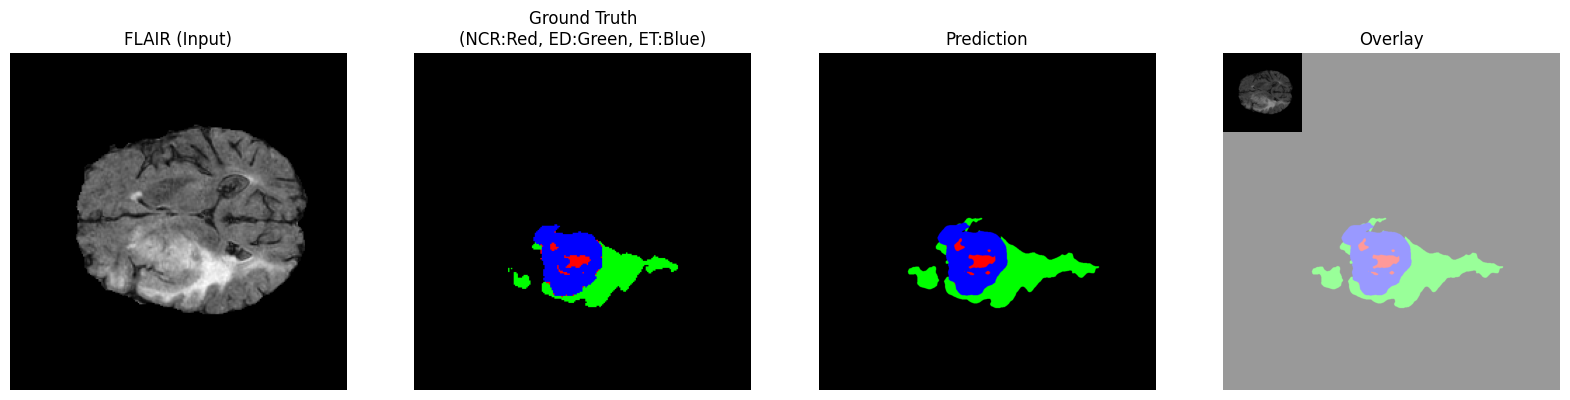

   ✅ 已保存: /storage/main/users/leishen/output/vis_results/vis_sample_1.png
   正在处理样本: BraTS20_Training_151, Slice: 108


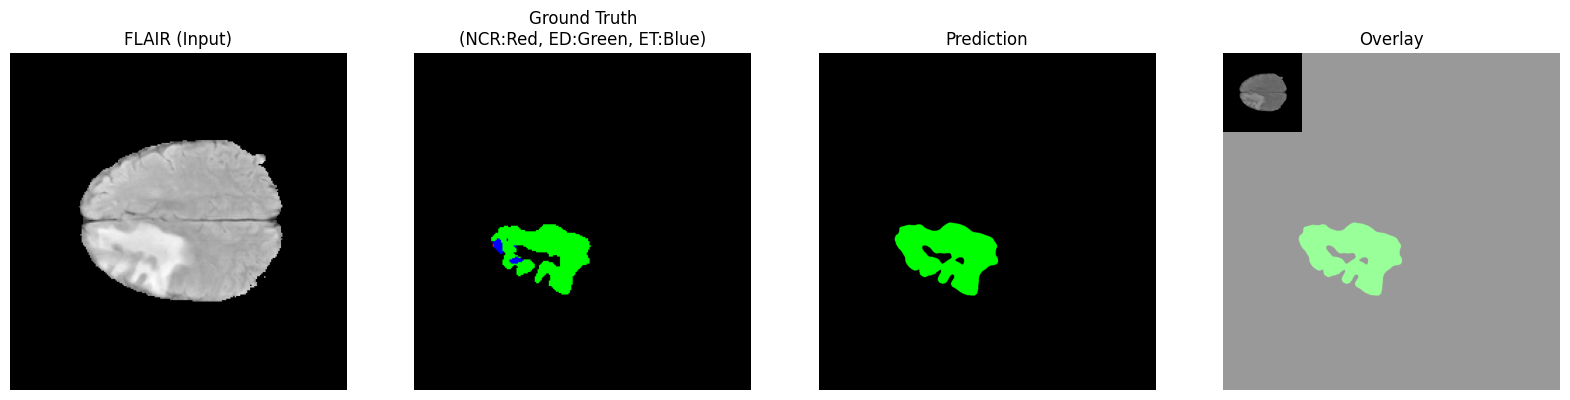

   ✅ 已保存: /storage/main/users/leishen/output/vis_results/vis_sample_2.png
   正在处理样本: BraTS20_Training_309, Slice: 46


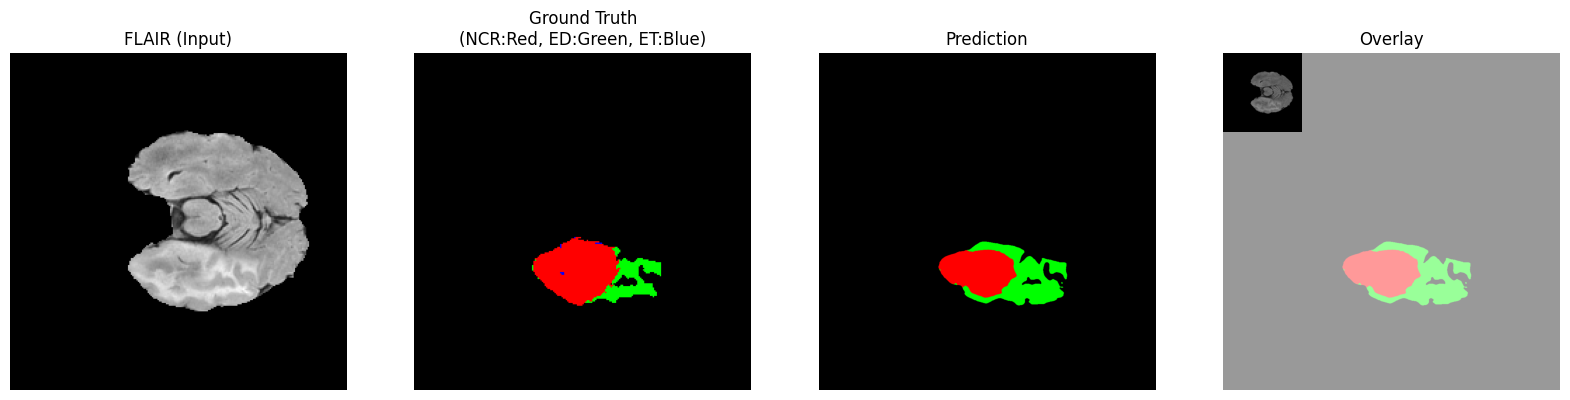

   ✅ 已保存: /storage/main/users/leishen/output/vis_results/vis_sample_3.png


In [43]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import random
import torch.nn.functional as F
from pathlib import Path
import os

# ==============================================================================
# 1. 查找并定义最佳权重路径
# ==============================================================================
# 根据训练代码逻辑，BEST 权重通常保存在 OUT_DIR 根目录下
ckpt_path = Path(OUT_DIR) / "swin_sam_unet_best.pt"

if not ckpt_path.exists():
    print(f"⚠️ 在 {ckpt_path} 未找到，尝试在 checkpoints 目录查找...")
    # 备用：尝试在 checkpoints 子目录下查找
    potential_files = list(Path(CHECKPOINT_DIR).glob("*best.pt"))
    if potential_files:
        ckpt_path = potential_files[0]
    else:
        raise FileNotFoundError(f"❌ 无法找到最佳模型权重文件 (swin_sam_unet_best.pt)")

print(f"📂 准备加载 Checkpoint: {ckpt_path}")

# ==============================================================================
# 2. 构建模型并修复结构 (关键步骤)
# ==============================================================================
print("🏗️ 重建模型结构...")

# 使用训练时的配置 (MODEL_CONFIG 应该在之前的 Cell 中已定义)
loaded_model = SwinSAMUNet(
    in_ch=MODEL_CONFIG['in_channels'],
    num_classes=MODEL_CONFIG['num_classes'],
    sam_type="vit_b",
    sam_ckpt=None,  # 这里不需要加载原始 SAM 权重，因为稍后会加载微调后的完整权重
    freeze_encoder=MODEL_CONFIG['freeze_encoder'],
    unfreeze_last_n=MODEL_CONFIG['unfreeze_layers'],
    enable_deep_supervision=MODEL_CONFIG['enable_deep_supervision'],
    use_swin=MODEL_CONFIG['use_swin'],
    swin_skip_levels=MODEL_CONFIG['swin_skip_levels'],
    swin_bottleneck_depth=MODEL_CONFIG['swin_bottleneck_depth']
)

# 🔥🔥🔥 关键修复：必须将 BatchNorm 再次转换为 GroupNorm 以匹配权重 🔥🔥🔥
print("🔄 执行 BatchNorm -> GroupNorm 转换...")
loaded_model = convert_batchnorm_to_groupnorm(loaded_model, num_groups=32)

# ==============================================================================
# 3. 加载权重
# ==============================================================================
print("📥 加载状态字典...")
checkpoint = torch.load(ckpt_path, map_location=device)

# 加载参数
loaded_model.load_state_dict(checkpoint['model'])
loaded_model.to(device)
loaded_model.eval()

print(f"✅ 模型加载成功！Epoch: {checkpoint.get('epoch', 'Unknown')}, Dice: {checkpoint.get('val_metrics', {}).get('mean_dice', 0):.4f}")

# ==============================================================================
# 4. 可视化函数 (保存到 OUT_DIR/vis_results)
# ==============================================================================
VIS_SAVE_DIR = os.path.join(OUT_DIR, "vis_results")
os.makedirs(VIS_SAVE_DIR, exist_ok=True)

def visualize_prediction(model, dataset_files, num_samples=3):
    print(f"\n🎨 开始可视化 {num_samples} 个样本...")
    
    # 随机选择样本
    if not dataset_files:
        print("❌ 没有验证集数据，无法可视化")
        return
        
    indices = random.sample(range(len(dataset_files)), min(num_samples * 5, len(dataset_files)))
    count = 0
    
    for idx in indices:
        if count >= num_samples: break
        
        fd = dataset_files[idx]
        
        # 寻找有肿瘤的切片 (Label > 0)
        lbl_vol = nib.load(fd['label']).get_fdata().astype(np.int16)
        # 将标签 4 转换为 3 (BraTS 标准)
        lbl_vol = np.where(lbl_vol == 4, 3, lbl_vol)
        
        pos_slices = [z for z in range(lbl_vol.shape[-1]) if (lbl_vol[..., z] > 0).any()]
        
        if not pos_slices:
            continue  # 跳过没有肿瘤的样本
            
        # 随机选一个有肿瘤的切片
        z = random.choice(pos_slices)
        count += 1
        
        print(f"   正在处理样本: {Path(fd['flair']).parent.name}, Slice: {z}")
        
        # 加载切片数据
        img_np, lbl_np, inp_tensor = load_slice(fd, z, size=IMAGE_SIZE)
        
        # 推理
        with torch.no_grad():
            output = model(inp_tensor.to(device))
            # 处理深度监督的输出 (可能是 tuple)
            if isinstance(output, tuple):
                output = output[0]
            pred_mask = torch.argmax(output, dim=1).cpu().numpy()[0] # (H, W)
            
        # 如果推理尺寸和原始尺寸不一致，简单缩放回可视化尺寸（这里假设 load_slice 已经处理了 resize，或者直接可视化 resize 后的结果）
        # 为了展示方便，我们直接展示 1024x1024 的输入和输出
        
        # --- 绘图 ---
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
        # 1. FLAIR 图像
        axes[0].imshow(img_np[0], cmap='gray')
        axes[0].set_title("FLAIR (Input)")
        axes[0].axis('off')
        
        # 2. Ground Truth
        # 创建彩色 Label
        gt_color = np.zeros((*lbl_np.shape, 3), dtype=np.uint8)
        # 红色: NCR (1), 绿色: EDEMA (2), 蓝色: ENHANCING (3)
        gt_color[lbl_np == 1] = [255, 0, 0]
        gt_color[lbl_np == 2] = [0, 255, 0]
        gt_color[lbl_np == 3] = [0, 0, 255]
        
        axes[1].imshow(gt_color)
        axes[1].set_title(f"Ground Truth\n(NCR:Red, ED:Green, ET:Blue)")
        axes[1].axis('off')
        
        # 3. Prediction
        pred_color = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)
        pred_color[pred_mask == 1] = [255, 0, 0]
        pred_color[pred_mask == 2] = [0, 255, 0]
        pred_color[pred_mask == 3] = [0, 0, 255]
        
        axes[2].imshow(pred_color)
        axes[2].set_title("Prediction")
        axes[2].axis('off')
        
        # 4. Overlay (FLAIR + Pred)
        axes[3].imshow(img_np[0], cmap='gray')
        axes[3].imshow(pred_color, alpha=0.4)
        axes[3].set_title("Overlay")
        axes[3].axis('off')
        
        # 保存图片
        save_path = os.path.join(VIS_SAVE_DIR, f"vis_sample_{count}.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=100)
        plt.show()
        print(f"   ✅ 已保存: {save_path}")

# 运行可视化 (使用验证集)
# 注意：确保 val_files_dict 变量在当前内存中存在
if 'val_files_dict' in globals():
    visualize_prediction(loaded_model, val_files_dict, num_samples=3)
else:
    print("⚠️ 警告: 未找到验证集数据列表 'val_files_dict'，无法运行可视化。请确保之前的 Data Load Cells 已运行。")